# A first quantum simulation — a free Gaussian wave packet on a ring

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 1 — Computational toolbox*

## 1. Introduction: the case for simulation, and for starting here

Welcome. This is the **first notebook of the course**, and quite possibly the first time you will use a computer
not as a calculator but as a *laboratory* — a place where a quantum system is set up, evolved in time, measured,
and compared with what pencil and paper predict.

### 1.1 Theory, numerics, experiment

Physics has three legs. **Theory** produces equations and, in the lucky cases, closed-form solutions.
**Experiment** produces numbers with error bars. **Numerics** sits in between: it takes the equations
seriously, solves them on a computer for systems that are far too complicated for pencil and paper, and produces
numbers that can be compared with both. Almost everything we know quantitatively about interacting quantum matter —
superconductors, cold atoms in optical lattices, the noise in a real quantum processor — comes
from that third leg.

A **numerical simulation** always follows the same four steps:

1. **A continuous equation.** Here: the Schrödinger equation, an equation for a function $\psi(x,t)$ of a
   continuous variable $x$ — infinitely many numbers.
2. **Discretisation.** We replace the continuum by a *finite* set of numbers: the values of $\psi$ at $N_x$
   selected points $x_0, x_1, \ldots, x_{N_x-1}$. A computer can hold those. Derivatives, integrals and the
   equation itself must be re-expressed in terms of this finite list.
3. **An algorithm.** A recipe that turns the list at time $t$ into the list at time $t + \Delta t$ — a finite
   number of additions and multiplications.
4. **A result with a controllable error.** This is the part beginners forget. The output is *never* the exact
   answer. It differs from it by a **discretisation error** (we used $N_x$ points instead of infinitely many) and
   by a **round-off error** (the computer stores each number with about $16$ decimal digits). A simulation is
   only worth something if you can show that these errors are small *and that you know how to make them smaller*.

### 1.2 Why our first system has a known exact solution

There is an iron rule in computational physics:

> **Numerical practice.** Never trust a simulation you have not tested against something you know independently.
> The first run of any new code is on a problem whose answer you already have — an exact solution, a
> conservation law, a known limit, or a second, completely different algorithm.

The reason is brutal: a program with a wrong sign, a factor of $2$, or an index off by one will happily run and
produce smooth, plausible, beautifully coloured, *wrong* pictures. Nothing in the output says "I am wrong".
The only defence is a reference.

The **free particle** — no forces, no potential — is the perfect first patient. Its Schrödinger equation can be
solved in closed form for a Gaussian initial state, giving formulas for the position, the width, and the full
wave function at any time. So we can put the exact curve and the computed curve on the same plot and *measure*
the distance between them.

And "agreement" has a precise meaning. It does **not** mean "the curves look the same". It means:
*the difference shrinks, when we refine the grid, in the way the theory of the method predicts* — for the
finite-difference method we will derive, the error must fall like $(\Delta x)^2$; halve the grid spacing and the
error must drop by a factor of four. If it does, the code is almost certainly right. If it does not, something
is broken, even when the pictures look fine.

### 1.3 The physics: a spreading wave packet

The system itself is the "hello world" of quantum dynamics. A particle is prepared in a **Gaussian wave packet**:
a lump of probability of width $\sigma_0$, centred at $x_c$, carrying an average momentum $\hbar k_0$. It is the
closest a quantum particle gets to a classical particle with a definite position and velocity. Then we let go.
Two things happen at once:

* the lump **moves** with the group velocity $\hbar k_0/m$, exactly as a classical particle would;
* the lump **spreads**, because a localised state necessarily contains a range of momenta
  ($\sigma_x \sigma_k \ge 1/2$ — the uncertainty relation), and different momentum components travel at
  different speeds. The spreading has no classical analogue whatsoever.

This is not an academic exercise. It is what happens

* to an **electron** emitted from a tip or a photocathode, and in every simulation of electron transport;
* to a cloud of **ultracold atoms** the instant the trap holding it is switched off — the standard
  "time-of-flight" measurement in every cold-atom laboratory reads the momentum distribution off the
  expansion of the cloud;
* in **matter-wave interferometry**, where a single atom or molecule is split into two packets that
  spread, travel, and are recombined to interfere.

The numbers differ wildly. We will compute them in Section 2, but here is the punchline: a $1\,\mathrm{nm}$
electron packet doubles its width in a few tens of femtoseconds, while a $1\,\mu\mathrm{m}$ cloud of rubidium
atoms takes a few milliseconds — eleven orders of magnitude apart, and yet, as we will see, *the same
simulation* describes both.

### 1.4 Road map

* **Section 2** — the free Schrödinger equation in SI units, and **non-dimensionalisation**: how we strip
  $\hbar$ and $m$ out of the equation by measuring lengths, times and energies in units built from the problem
  itself. This is done once, very slowly, because we will do it in every notebook of this course.
* **Section 3** — the exact solution, derived in full: Fourier transform, Gaussian integral, free propagation,
  transform back. Results: $\langle x \rangle(t)$, $\sigma(t)$, the chirp, the uncertainty product.
* **Section 4** — the **grid**: what an array holds, what periodic boundary conditions mean, which wave numbers
  a grid can represent, and what happens when you ask for one it cannot (aliasing).
* **Section 5** — first contact with the numbers: build the packet, check its norm, mean position and width with
  sums instead of integrals.
* **Section 6** — **method A, finite differences**: Taylor expansion, the three-point Laplacian, the circulant
  Hamiltonian, its exact eigenvalues, and the *numerical dispersion relation* — the reason a finite-difference
  packet moves slightly too slowly.
* **Section 7** — **method B, the Fourier (spectral) method**: with periodic boundaries the kinetic energy is
  diagonal in Fourier space, so one FFT, one multiplication and one inverse FFT give the exact answer.
* **Section 8** — **expectation values and variances**, analytics and numerics side by side: Ehrenfest's
  theorem, $\langle x\rangle$, $\langle p\rangle$, $\mathrm{Var}(x)$, $\mathrm{Var}(p)$, the covariance, the
  uncertainty product — and two different ways of computing momenta on a grid.
* **Section 9** — the numerics-versus-analytics verdict: convergence plots, conservation laws, cost.
* **Section 10** — **animations**: a reusable function that turns a stack of snapshots into an animated GIF
  embedded in the notebook.
* **Section 11** — what the ring does to us: wrap-around, self-interference, the image sum, and exact revivals.
* **Section 12** — summary, a reusable **workflow checklist**, exercises and references.

### What you will learn

*Physics*

* the free Gaussian wave packet: group velocity, spreading law $\sigma(t) = \sigma_0\sqrt{1 + (t/2\sigma_0^2)^2}$,
  the position-dependent "chirp", phase velocity versus group velocity, the growth of the uncertainty product;
* why a momentum distribution never changes for a free particle;
* Ehrenfest's theorem ($d\langle x\rangle/dt = \langle p\rangle$), the ballistic variance law
  $\mathrm{Var}(x)(t) = \mathrm{Var}(x)(0) + \mathrm{Var}(p)\,t^2$ and the position-momentum covariance;
* what periodic boundary conditions do: self-interference and exact quantum revivals on a ring.

*Numerical methods*

* non-dimensionalisation; grids, discretisation error, round-off error, machine precision;
* the three-point Laplacian and its $O(\Delta x^2)$ error; circulant matrices and their plane-wave eigenvectors;
* numerical dispersion; the sampling theorem and aliasing;
* the Fourier (spectral) method, `fft`/`ifft`/`fftfreq`, spectral accuracy, $O(N\log N)$ cost;
* how to run and read a convergence test (log-log plot, fitted slope).

*Implementation practice*

* turning integrals into array sums, and formulas into vectorised code;
* `jax.jit`, `jax.vmap` and `lax.scan` in their simplest possible setting (each explained in two sentences);
* validating every step with `assert` against the analytic result;
* producing animated GIFs from matplotlib and embedding them in a notebook without leaving files behind.

### Prerequisites

One semester of quantum mechanics (the Schrödinger equation, wave functions, the Born rule, Fourier transforms at
the level of "plane waves are momentum eigenstates") and basic Python with NumPy and matplotlib.
**No numerical-methods background and no JAX knowledge are assumed.**

### Where this notebook sits

It is the first one. Its direct continuation is
[00b — a first quantum simulation: the harmonic oscillator](00b_first_quantum_simulation_harmonic_oscillator.ipynb),
which adds a **potential**, builds the Hamiltonian as a matrix, *diagonalises* it to get stationary states and
energies, quenches the trap frequency, and compares matrix-exponential propagation with a Runge–Kutta
integrator. Everything about potentials, eigenstates and ODE integrators is left to that notebook; here the
particle is free. After it comes
[01 — JAX from scratch](01_jax_from_scratch.ipynb), which explains properly the library we use for the heavy
lifting. Today we use only three of its features and explain each one where it appears.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. The equation, and how to get rid of $\hbar$ and $m$

### 2.1 The free Schrödinger equation in SI units

A particle of mass $m$ moving in one dimension with no forces acting on it is described by a wave function
$\Psi(X,T)$ obeying

$$ i\hbar \frac{\partial \Psi(X,T)}{\partial T} \;=\; -\frac{\hbar^2}{2m}\frac{\partial^2 \Psi(X,T)}{\partial X^2} . \tag{1} $$

Capital $X$ and $T$ are a position in metres and a time in seconds. The right-hand side is the kinetic-energy
operator $\hat p^2/2m$ with $\hat p = -i\hbar\,\partial_X$; there is no potential term, which is exactly what
"free" means. The physical content of $\Psi$ is the Born rule: $\vert\Psi(X,T)\vert^2\,dX$ is the probability of
finding the particle in $[X, X+dX]$, and

$$ \int_{-\infty}^{\infty} \vert\Psi(X,T)\vert^2 \, dX = 1 \qquad \text{for all } T . $$

### 2.2 Why we never type $\hbar$ into a computer

In SI units $\hbar \approx 1.05\times10^{-34}\,\mathrm{J\,s}$ and an electron mass is
$\approx 9.1\times10^{-31}\,\mathrm{kg}$. If we fed
those numbers to a computer, every intermediate quantity would be a tiny or a huge number, we could not tell a
"small" error from a "large" one, and — worse — the result would be specific to one particle. The cure is
**non-dimensionalisation**: measure every quantity in units built out of the problem itself, so that the equation
contains only pure numbers.

Here comes the subtlety that makes the free particle special. Equation (1) contains two constants,
$\hbar$ and $m$. From them alone you *cannot* build a length: $\hbar$ has units
$\mathrm{J\,s} = \mathrm{kg\,m^2\,s^{-1}}$ and $m$ has units $\mathrm{kg}$, so $\hbar/m$ has units
$\mathrm{m^2\,s^{-1}}$ — a diffusion constant, not a length. **The free particle has no intrinsic length scale.**
(A harmonic trap of frequency $\omega$ would supply one, $\sqrt{\hbar/m\omega}$; that is the story of notebook 00b.)

So *we* choose one. The only length in the problem is the one we put into the initial state: the initial width
$\sigma_0$ of the packet. Define

$$ x_0 \equiv \sigma_0 \qquad (\text{unit of length}). $$

### 2.3 Substituting the scaled variables

Write the position and the time as (a pure number) $\times$ (a unit):

$$ X = x_0\, x , \qquad T = t_0\, t , $$

where $x$ and $t$ are dimensionless and $t_0$ is a unit of time still to be chosen. By the chain rule,

$$ \frac{\partial}{\partial T} = \frac{1}{t_0}\frac{\partial}{\partial t}, \qquad
   \frac{\partial^2}{\partial X^2} = \frac{1}{x_0^2}\frac{\partial^2}{\partial x^2} . $$

The wave function must be rescaled too, because it is not dimensionless: $\vert\Psi\vert^2$ is a probability
*density*, so $\Psi$ has units $\mathrm{m}^{-1/2}$. Define

$$ \psi(x,t) \;\equiv\; \sqrt{x_0}\; \Psi(x_0 x,\; t_0 t) . $$

The factor $\sqrt{x_0}$ is exactly what is needed to preserve the normalisation:

$$ \int \vert\Psi\vert^2\, dX \;=\; \int \frac{\vert\psi\vert^2}{x_0}\; x_0\, dx \;=\; \int \vert\psi\vert^2\, dx \;=\; 1 . $$

Substituting into Eq. (1) and cancelling the common factor $x_0^{-1/2}$:

$$ \frac{i\hbar}{t_0}\,\frac{\partial \psi}{\partial t} \;=\; -\frac{\hbar^2}{2m x_0^2}\,\frac{\partial^2 \psi}{\partial x^2} . $$

Now divide both sides by the energy unit $E_0 \equiv \hbar/t_0$:

$$ i\,\frac{\partial \psi}{\partial t} \;=\; -\frac{\hbar\, t_0}{2m x_0^{2}}\,\frac{\partial^2 \psi}{\partial x^2} . $$

The factor in front of the derivative, $\hbar t_0/(m x_0^2)$, is a pure number — check the units:
$\mathrm{J\,s}\cdot\mathrm{s}/(\mathrm{kg}\,\mathrm{m^2}) = 1$ — and $t_0$ is still ours to choose. Choose it
so that the whole coefficient is exactly $1/2$:

$$ \frac{\hbar\, t_0}{m x_0^{2}} = 1 \qquad \Longrightarrow \qquad \boxed{\; t_0 = \frac{m x_0^{2}}{\hbar} \;} $$

and the equation becomes, once and for all,

$$ i\,\frac{\partial \psi(x,t)}{\partial t} \;=\; -\frac{1}{2}\,\frac{\partial^2 \psi(x,t)}{\partial x^2} . \tag{2} $$

No $\hbar$, no $m$. **This is the equation we will solve for the rest of the notebook.** In these units
$\hbar = 1$ and $m = 1$ — a phrase you will meet constantly in the literature, and now you know precisely what it
is short for.

### 2.4 The full set of units

Everything else follows from $x_0$ and $t_0 = m x_0^2/\hbar$:

| quantity | unit | in terms of $x_0$ |
|---|---|---|
| length | $x_0 = \sigma_0$ | chosen |
| time | $t_0 = m x_0^2/\hbar$ | derived |
| energy | $E_0 = \hbar/t_0 = \hbar^2/(m x_0^2)$ | derived |
| wave number | $k_{\rm unit} = 1/x_0$ | reciprocal length |
| momentum | $p_0 = \hbar/x_0$ | since $p = \hbar k$ |
| velocity | $v_0 = x_0/t_0 = \hbar/(m x_0)$ | derived |

To go back to the real world you multiply by the unit. A dimensionless time $t = 3$ means
$T = 3\, m x_0^2/\hbar$ seconds; a dimensionless wave number $k = 2$ means a real momentum $2\hbar/x_0$.
Let us put numbers on that for our two physical examples.

In [2]:
# ==============================================================================
# STEP 0: the unit system, for two real experiments
#   We choose x_0 = sigma_0 (the initial width of the packet).  Everything else
#   follows:  t_0 = m x_0^2 / hbar,  E_0 = hbar / t_0,  v_0 = x_0 / t_0.
#   This cell is pure bookkeeping -- no quantum mechanics happens here.
# ==============================================================================
HBAR_SI = 1.054571817e-34        # reduced Planck constant           [J s]
M_ELECTRON = 9.1093837015e-31    # electron mass                     [kg]
AMU = 1.66053906660e-27          # atomic mass unit                  [kg]
M_RB87 = 87.0 * AMU              # mass of a rubidium-87 atom        [kg]
EV = 1.602176634e-19             # one electronvolt                  [J]


def unit_system(mass_kg, x0_m):
    """Units of the non-dimensional free Schrodinger equation, for a given mass and length unit.

    MATH
        t_0 = m x_0^2 / hbar      (unit of time)
        E_0 = hbar / t_0 = hbar^2 / (m x_0^2)   (unit of energy)
        v_0 = x_0 / t_0 = hbar / (m x_0)        (unit of velocity)
    Returns a dict of floats in SI units.
    """
    t0 = mass_kg * x0_m**2 / HBAR_SI
    return {"x0_m": x0_m, "t0_s": t0, "E0_J": HBAR_SI / t0, "v0_mps": x0_m / t0}


cases = [("electron,  x_0 = 1 nm     ", M_ELECTRON, 1e-9),
         ("Rb-87 atom, x_0 = 1 micron", M_RB87, 1e-6)]

print(f"{'system':28s} {'t_0 [s]':>12s} {'E_0 [J]':>12s} {'E_0 [eV]':>12s} {'E_0/h [Hz]':>12s} {'v_0 [m/s]':>12s}")
for name, mass, x0 in cases:
    u = unit_system(mass, x0)
    print(f"{name:28s} {u['t0_s']:12.3e} {u['E0_J']:12.3e} {u['E0_J']/EV:12.3e} "
          f"{u['E0_J']/(2*np.pi*HBAR_SI):12.3e} {u['v0_mps']:12.3e}")

# The spreading time (derived in Section 3): the packet's width has grown by sqrt(2)
# after t = 2 sigma_0^2 in our units, i.e. after T_spread = 2 m sigma_0^2 / hbar in seconds.
print()
for name, mass, x0 in cases:
    t_spread = 2.0 * mass * x0**2 / HBAR_SI
    print(f"{name:28s} spreading time T_s = 2 m sigma_0^2/hbar = {t_spread:10.3e} s")

system                            t_0 [s]      E_0 [J]     E_0 [eV]   E_0/h [Hz]    v_0 [m/s]
electron,  x_0 = 1 nm           8.638e-15    1.221e-20    7.620e-02    1.842e+13    1.158e+05
Rb-87 atom, x_0 = 1 micron      1.370e-03    7.698e-32    4.805e-13    1.162e+02    7.300e-04

electron,  x_0 = 1 nm        spreading time T_s = 2 m sigma_0^2/hbar =  1.728e-14 s
Rb-87 atom, x_0 = 1 micron   spreading time T_s = 2 m sigma_0^2/hbar =  2.740e-03 s


### 2.5 Reading the table

For an electron localised to $1\,\mathrm{nm}$ the natural time unit is about $8.6\,\mathrm{fs}$ and the natural
energy about $76\,\mathrm{meV}$ — femtosecond physics, as anyone doing ultrafast spectroscopy will confirm. The
packet needs $T_s = 2 m\sigma_0^2/\hbar \approx 17\,\mathrm{fs}$ to grow from $1\,\mathrm{nm}$ to
$\sqrt{2}\,\mathrm{nm}$. An electron simply cannot be kept localised.

For a rubidium-87 atom localised to $1\,\mu\mathrm{m}$ — a typical cold-atom cloud — the time unit is about
$1.4\,\mathrm{ms}$ and the energy unit corresponds to about $116\,\mathrm{Hz}$, which is why cold-atom
experiments quote trap frequencies in hertz and expansion times in milliseconds. The cloud needs
$\approx 2.7\,\mathrm{ms}$ to spread by $\sqrt 2$: comfortable to photograph with a camera.

The two unit systems differ by eleven orders of magnitude, both in time and in energy: the ratios are
$t_0^{\rm Rb}/t_0^{\rm e} = 1.4\times10^{-3}/8.6\times10^{-15} = 1.6\times10^{11}$ and
$E_0^{\rm e}/E_0^{\rm Rb} = 1.2\times10^{-20}/7.7\times10^{-32} = 1.6\times10^{11}$ — necessarily the *same*
factor, because $t_0 = m x_0^2/\hbar$ and $E_0 = \hbar^2/(m x_0^2)$ are reciprocal up to $\hbar$. And **both
systems are described by the same dimensionless Eq. (2)**. One simulation, many experiments. That is the whole point of
non-dimensionalisation, and the reason it is the first step of the workflow checklist we will assemble at the
end.

> **Numerical practice.** Non-dimensionalise *before* you write code. Besides the physics argument above, there
> is an arithmetic one: computers represent numbers of order $1$ with the smallest relative error, and a code
> whose variables are all of order $1$ is one where a printed value of $10^{-12}$ unambiguously means "zero to
> round-off" and $10^{3}$ means "something is wrong".

## 3. The exact solution, derived in full

Before we compute anything we solve the problem on paper. This is our reference: every number the computer
produces will be compared with a formula from this section.

### 3.1 The initial state

We start from a **Gaussian wave packet with an imprinted momentum**:

$$ \psi(x,0) \;=\; \left(2\pi\sigma_0^{2}\right)^{-1/4}\,
   \exp\!\left[-\frac{(x-x_c)^{2}}{4\sigma_0^{2}}\right]\, e^{\, i k_0 x} . \tag{3} $$

Three parameters: the centre $x_c$, the width $\sigma_0$, the central wave number $k_0$. Note the **4** in the
denominator of the exponent: the *amplitude* has width $2\sigma_0$ so that the *density* has width $\sigma_0$,

$$ \vert\psi(x,0)\vert^{2} \;=\; \frac{1}{\sqrt{2\pi\sigma_0^{2}}}\,
   \exp\!\left[-\frac{(x-x_c)^{2}}{2\sigma_0^{2}}\right] , $$

which is the standard normal density with standard deviation $\sigma_0$, so
$\langle x\rangle = x_c$ and $\langle x^2\rangle - \langle x\rangle^2 = \sigma_0^2$. The plane-wave factor
$e^{ik_0x}$ has modulus one and therefore does not change the density at all; it is a pure phase whose gradient
*is* the local momentum, since

$$ \hat p\, e^{ik_0x} = -i\frac{\partial}{\partial x}e^{ik_0x} = k_0\, e^{ik_0x} $$

(recall $\hbar=1$ in our units). Imprinting $e^{ik_0x}$ is the quantum way of saying "and now give it a kick".

### 3.2 Step 1 — go to momentum space

The free Hamiltonian is a function of $\hat p$ alone, so it is diagonal in the momentum basis. Define the Fourier
transform with the symmetric convention

$$ \phi(k) \;=\; \frac{1}{\sqrt{2\pi}}\int_{-\infty}^{\infty} \psi(x)\, e^{-ikx}\, dx , \qquad
   \psi(x) \;=\; \frac{1}{\sqrt{2\pi}}\int_{-\infty}^{\infty} \phi(k)\, e^{ikx}\, dk . $$

Insert Eq. (3), call $A = (2\pi\sigma_0^2)^{-1/4}$ and substitute $u = x - x_c$:

$$ \phi(k,0) \;=\; \frac{A}{\sqrt{2\pi}}\; e^{\, i(k_0-k)x_c} \int_{-\infty}^{\infty}
   \exp\!\left[-\frac{u^{2}}{4\sigma_0^{2}} + i(k_0-k)u\right] du . $$

The integral is the **Gaussian integral**, which we do by *completing the square*. For any complex $a$ with
$\mathrm{Re}\,a > 0$ (so that the integrand decays) and any complex $b$,

$$ \int_{-\infty}^{\infty} e^{-au^{2}+bu}\, du
   = \int_{-\infty}^{\infty} e^{-a\left(u - \frac{b}{2a}\right)^{2}}\, du \; e^{\frac{b^{2}}{4a}}
   = \sqrt{\frac{\pi}{a}}\; e^{\frac{b^{2}}{4a}} . \tag{4} $$

Two remarks, because we will use this formula twice and the second time $a$ will be complex. (i) Shifting the
integration contour from the real axis to the line $\mathrm{Im}\,u = \mathrm{Im}(b/2a)$ is legitimate: the
integrand is entire (no poles to cross) and decays as $\vert\mathrm{Re}\,u\vert\to\infty$ uniformly in the
strip between the two lines, so the two vertical connecting pieces contribute nothing. (ii) For real positive
$a$ the result is the elementary $\int e^{-au^2}du = \sqrt{\pi/a}$; both sides of Eq. (4) are analytic
functions of $a$ on the half-plane $\mathrm{Re}\,a>0$, which is connected, so agreeing on the positive real
axis they agree everywhere on it — provided $\sqrt{\cdot}$ means the **principal** branch (the one with
positive real part), which is exactly what `numpy.sqrt` computes for complex arguments.
With $a = 1/(4\sigma_0^2)$ and $b = i(k_0-k)$,

$$ \int \exp\!\left[-\frac{u^2}{4\sigma_0^2} + i(k_0-k)u\right] du
   = 2\sigma_0\sqrt{\pi}\;\exp\!\left[-\sigma_0^{2}(k-k_0)^{2}\right] , $$

and therefore

$$ \phi(k,0) \;=\; \left(\frac{2\sigma_0^{2}}{\pi}\right)^{1/4}
   \exp\!\left[-\sigma_0^{2}(k-k_0)^{2}\right]\, e^{-i(k-k_0)x_c} . \tag{5} $$

A Gaussian in $x$ is a Gaussian in $k$. Its density is
$\vert\phi\vert^2 \propto \exp[-(k-k_0)^2/(2\sigma_k^2)]$ with

$$ \sigma_k \;=\; \frac{1}{2\sigma_0} , \qquad\text{so}\qquad \sigma_x \sigma_k = \tfrac12 \;\; \text{at } t=0 : $$

the Gaussian packet is a **minimum-uncertainty state**. Narrow in $x$ means wide in $k$ — remember this, it is
the cause of everything that follows.

### 3.3 Step 2 — evolve, which in momentum space is trivial

In momentum space Eq. (2) reads $i\,\partial_t \phi(k,t) = \tfrac{k^2}{2}\,\phi(k,t)$, because each derivative
$\partial_x$ becomes a multiplication by $ik$. That is an ordinary differential equation for each $k$
separately, with the immediate solution

$$ \phi(k,t) \;=\; e^{-i \omega(k) t}\,\phi(k,0), \qquad \omega(k) = \frac{k^{2}}{2} . \tag{6} $$

This is the **dispersion relation** of a free non-relativistic particle: $\omega = k^2/2$, i.e.
$E = \hbar^2k^2/2m$ in SI units. Two consequences you should read off immediately:

* $\vert\phi(k,t)\vert = \vert\phi(k,0)\vert$: **the momentum distribution never changes.** A free particle
  cannot change its momentum — there is no force. Every measurable property of the momentum ($\langle p\rangle$,
  $\sigma_p$, the whole distribution) is a constant of the motion. This will be one of our numerical checks.
* Different $k$ evolve with different phase velocities $\omega(k)/k = k/2$. A superposition of many $k$ therefore
  gets out of step with itself — and *that* is why the packet spreads.

### 3.4 Step 3 — transform back

Insert Eq. (5) into the inverse transform and substitute $q = k-k_0$:

$$ \psi(x,t) \;=\; \frac{1}{\sqrt{2\pi}}\left(\frac{2\sigma_0^{2}}{\pi}\right)^{1/4}
   \int_{-\infty}^{\infty} \exp\!\left[-\sigma_0^{2}q^{2} - iq x_c - \frac{i t}{2}(q+k_0)^{2} + i(q+k_0)x\right] dq . $$

Expand $(q+k_0)^2 = q^2 + 2k_0q + k_0^2$ and sort the exponent by powers of $q$:

$$ \begin{aligned}
   \text{exponent} &= -\left(\sigma_0^{2} + \frac{it}{2}\right)q^{2}
      \; +\; i\,\underbrace{\left(x - x_c - k_0 t\right)}_{\textstyle \equiv\, X}\, q
      \;+\; i\left(k_0 x - \frac{k_0^{2}t}{2}\right) .
   \end{aligned} $$

The variable $X = x - x_c - k_0 t$ is the position measured **in the frame moving with the packet**. Apply the
Gaussian formula (4) again, now with $a = \sigma_0^2 + it/2$ (which has $\mathrm{Re}\,a = \sigma_0^2 > 0$, so
remark (ii) above applies) and $b = iX$, using $b^2/4a = -X^2/4a$:

$$ \int e^{-aq^{2}+bq}\,dq = \sqrt{\frac{\pi}{a}}\;\exp\!\left[-\frac{X^{2}}{4a}\right] . $$

Now collect the prefactors. Write $a = \sigma_0^{2}(1+i\tau)$ with $\tau \equiv t/(2\sigma_0^{2})$ — that is
just $it/2 = \sigma_0^2 \cdot i\tau$ — so that $\sqrt{\pi/a} = \sqrt{\pi}\,\sigma_0^{-1}(1+i\tau)^{-1/2}$.
The constant in front of the integral was $\frac{1}{\sqrt{2\pi}}\left(2\sigma_0^2/\pi\right)^{1/4}$, so

$$ \begin{aligned}
   \text{prefactor} &= \frac{1}{\sqrt{2\pi}}\left(\frac{2\sigma_0^{2}}{\pi}\right)^{1/4}
       \frac{\sqrt{\pi}}{\sigma_0\sqrt{1+i\tau}}
    = \underbrace{\frac{\sqrt{\pi}}{\sqrt{2\pi}}}_{=\,2^{-1/2}}\;
      \underbrace{\frac{2^{1/4}\sigma_0^{1/2}}{\pi^{1/4}\,\sigma_0}}_{=\,2^{1/4}\pi^{-1/4}\sigma_0^{-1/2}}
      \frac{1}{\sqrt{1+i\tau}} \\
   &= \frac{2^{-1/4}\,\pi^{-1/4}\,\sigma_0^{-1/2}}{\sqrt{1+i\tau}}
    = \frac{\left(2\pi\sigma_0^{2}\right)^{-1/4}}{\sqrt{1+i\tau}} ,
   \end{aligned} $$

and likewise $-X^2/(4a) = -X^2/\left[4\sigma_0^2(1+i\tau)\right]$. The **final result** is therefore

$$ \boxed{\;\psi(x,t) \;=\; \frac{\left(2\pi\sigma_0^{2}\right)^{-1/4}}{\sqrt{1+i\tau}}\;
   \exp\!\left[-\frac{X^{2}}{4\sigma_0^{2}\left(1+i\tau\right)}\right]\,
   \exp\!\left[\,i\left(k_0 x - \frac{k_0^{2}t}{2}\right)\right] \;}
   \qquad \tau \equiv \frac{t}{2\sigma_0^{2}},\quad X = x-x_c-k_0t . \tag{7} $$

### 3.5 Reading the answer

**(a) The density.** Split $\frac{1}{1+i\tau} = \frac{1-i\tau}{1+\tau^2}$. The real part of the exponent gives

$$ \vert\psi(x,t)\vert^{2} \;=\; \frac{1}{\sqrt{2\pi\sigma^{2}(t)}}\,
   \exp\!\left[-\frac{\left(x - x_c - k_0 t\right)^{2}}{2\sigma^{2}(t)}\right] , $$

a Gaussian at all times, with

$$ \langle x\rangle(t) = x_c + k_0 t , \qquad
   \sigma(t) = \sigma_0\sqrt{1+\tau^{2}} = \sigma_0\sqrt{1 + \left(\frac{t}{2\sigma_0^{2}}\right)^{2}} . \tag{8} $$

The centre moves with constant velocity $k_0$ — in SI units $\hbar k_0/m = p_0/m$, precisely the classical
velocity (this is Ehrenfest's theorem for a free particle). The width grows: slowly at first
($\sigma \approx \sigma_0(1+\tau^2/2)$, quadratically in $t$), then linearly,
$\sigma(t)\to \sigma_0 \tau = t/(2\sigma_0)= \sigma_k t$, which is nothing but "the packet expands at the spread
of its own velocities". The cross-over happens at $\tau = 1$, i.e. at the **spreading time**

$$ t_s = 2\sigma_0^{2} \qquad\Longleftrightarrow\qquad T_s = \frac{2m\sigma_0^{2}}{\hbar}\ \text{in SI units} , $$

the number we tabulated in Section 2. Note the counter-intuitive scaling: **narrower packets spread faster**
($t_s \propto \sigma_0^2$), because they contain a wider range of momenta.

**(b) The chirp.** The imaginary part of the exponent gives a phase that is *quadratic in $X$*:

$$ \theta(x,t) = k_0x - \frac{k_0^{2}t}{2} + \frac{\tau\,X^{2}}{4\sigma_0^{2}(1+\tau^{2})} - \frac12\arctan\tau . $$

The **local wave number** is its gradient,

$$ k_{\rm loc}(x,t) = \frac{\partial\theta}{\partial x} = k_0 + \frac{t\,X}{4\sigma_0^{2}\sigma^{2}(t)}
   \;\xrightarrow[t\gg t_s]{}\; k_0 + \frac{X}{t} . $$

Read that last formula aloud: at long times, the part of the packet sitting a distance $X$ ahead of the centre is
precisely the part whose velocity is $X/t$ — it got there because it was moving that fast. The packet sorts
itself in space by velocity, exactly like runners after the start of a race. In optics the same phenomenon is
called a **chirp** (the instantaneous frequency sweeps across the pulse), and we will see it in an animation of
$\mathrm{Re}\,\psi$: the oscillations are stretched on one side and compressed on the other.

**(c) The uncertainty product.** Since $\sigma_k$ is frozen and $\sigma(t)$ grows,

$$ \sigma_x(t)\,\sigma_k = \frac12\sqrt{1+\tau^{2}} \;\ge\; \frac12 , $$

with equality only at $t=0$. A free packet is a minimum-uncertainty state for one instant and never again.

**(d) Phase velocity versus group velocity.** A single plane wave $e^{i(kx-\omega t)}$ with $\omega = k^2/2$ has

$$ v_{\rm phase} = \frac{\omega}{k} = \frac{k}{2} , \qquad v_{\rm group} = \frac{d\omega}{dk} = k . $$

The **envelope** travels at $k_0$; the **ripples inside it** travel at only $k_0/2$, so in an animation of
$\mathrm{Re}\,\psi$ the individual crests continuously fall behind the lump and disappear at its rear edge.
For light in vacuum the two velocities coincide; for matter waves they differ by a factor of two. The famous
"velocity of a matter wave" of de Broglie is the group velocity — the one that carries the probability.

> **Physics insight.** Everything above came from one fact: $\omega(k)$ is *not* linear in $k$. A linear
> dispersion (light in vacuum, sound in air) transports any pulse shape rigidly and forever. A curved
> $\omega(k)$ makes pulses spread. In Section 6 we will discover that a careless *discretisation* changes
> $\omega(k)$ — and therefore changes the physics.

## 4. Putting the problem on a grid

### 4.1 A grid, and what an array holds

A computer cannot hold a function $\psi(x)$ — that is an uncountable infinity of numbers. It holds a finite
**array**. So we choose a finite interval $[0, L)$ and $N_x$ equally spaced points on it,

$$ x_j = j\,\Delta x, \qquad j = 0,1,\ldots,N_x-1, \qquad \Delta x = \frac{L}{N_x} , $$

and we store the $N_x$ complex numbers

$$ \psi_j \;\equiv\; \psi(x_j) . $$

That is all a "state" is in this notebook: `psi` is a NumPy/JAX array of shape `(N_x,)` and dtype `complex128`,
whose entry `psi[j]` is the value of the wave function at `x[j]`. The two knobs are $L$ (how much of the world
we keep) and $\Delta x$ (how finely we resolve it), and the two errors they cause — boundary effects and
discretisation error — are the two things we will have to control.

### 4.2 Integrals become sums

Every quantity we want is an integral, and every integral becomes a sum. For a smooth function sampled on a
uniform grid, the **Riemann sum** (here: the left-endpoint rectangle rule — we sample at $x_j = j\Delta x$ and
weight every sample by $\Delta x$. For a periodic function it *is* the trapezoidal rule: the trapezoidal rule
would give the endpoints $x_0$ and $x_{N_x}$ half weight each, and on a ring those two points are the same
point, so the two halves add up to one full $\Delta x$) reads

$$ \int_0^L f(x)\, dx \;\approx\; \Delta x \sum_{j=0}^{N_x-1} f(x_j) . $$

So the three quantities we care about are

$$ \mathcal{N} = \int \vert\psi\vert^{2} dx \;\to\; \Delta x \sum_j \vert\psi_j\vert^{2} , \qquad
   \langle x\rangle = \int x\,\vert\psi\vert^{2} dx \;\to\; \Delta x \sum_j x_j \vert\psi_j\vert^{2} , $$

$$ \sigma^{2} = \int (x - \langle x\rangle)^{2}\vert\psi\vert^{2} dx
   \;\to\; \Delta x \sum_j (x_j - \langle x\rangle)^{2}\,\vert\psi_j\vert^{2} . $$

For a *periodic and smooth* function this approximation is spectacularly good — the error decreases faster than
any power of $\Delta x$ (this is the trapezoidal rule's superpower on periodic functions; see Trefethen's book
in the references). We will verify it numerically in a moment.

### 4.3 Periodic boundary conditions: the particle lives on a ring

What happens at $x = 0$ and $x = L$? We impose **periodic boundary conditions**:

$$ \psi(x + L, t) = \psi(x, t) \qquad \Longleftrightarrow \qquad \psi_{N_x} \equiv \psi_0 . $$

Physically this is not a trick but a system: a particle confined to a **ring** of circumference $L$, free to
slide around it. Cold atoms are routinely trapped in exactly such ring geometries.

Numerically it is also the most convenient choice: there are no walls, so nothing reflects, and the
translational symmetry survives — which, as Section 7 will show, makes plane waves exact eigenstates of the
discretised Hamiltonian and hands us a very fast and very accurate algorithm. Its price is that a packet which
runs off the right edge comes back in on the left. As long as the packet is narrow and stays far from the seam,
the ring is indistinguishable from the infinite line; when it is not, the physics genuinely changes
(Section 11).

### 4.4 The wave numbers that fit on a ring

A plane wave $e^{ikx}$ is periodic with period $L$ only if $e^{ikL}=1$, that is

$$ k_n = \frac{2\pi n}{L}, \qquad n \in \mathbb{Z} . $$

On a grid of $N_x$ points there are exactly $N_x$ *distinguishable* such waves, conventionally taken as
$n = -N_x/2, \ldots, N_x/2-1$, because $e^{i k_{n+N_x} x_j} = e^{ik_n x_j}e^{2\pi i j} = e^{ik_n x_j}$: the
grid cannot tell $n$ from $n+N_x$. The largest wave number the grid represents is therefore

$$ k_{\max} = \frac{\pi}{\Delta x} \qquad \text{(the Nyquist wave number)} , $$

which is the **sampling theorem**: you need at least two grid points per wavelength. Two practical rules follow,
and violating either of them is the most common beginner's mistake in this business:

1. **Choose $k_0$ commensurate with the ring**, $k_0 = 2\pi m/L$ with integer $m$. Otherwise $e^{ik_0x}$ is not
   periodic, and the initial state has a discontinuity at the seam $x = L \equiv 0$.
2. **Keep the whole packet inside the band**: $k_0 + \text{a few}\,\sigma_k \ll \pi/\Delta x$. Otherwise the
   high-$k$ components are **aliased** — the grid silently reads a mode index $m$ as $m - N_x$, and as soon as
   $m > N_x/2$ that is *negative*, so the component travels backwards.

We will demonstrate both failures deliberately, because a failure you have seen once you will recognise forever.

### 4.5 `fftfreq`: the order the wave numbers come in

NumPy's `fft` returns the coefficients in the order $n = 0, 1, \ldots, N_x/2-1, -N_x/2, \ldots, -1$ — the
non-negative frequencies first, then the negative ones ("wrapped" order). Rather than remembering that, call
`np.fft.fftfreq(N_x, d=dx)`, which returns $n/(N_x\Delta x) = n/L$ in exactly the matching order; multiply by
$2\pi$ to get $k$:

```python
k = 2.0 * np.pi * np.fft.fftfreq(N_x, d=dx)
```

Let us build the grid and look at it.

In [3]:
# ==============================================================================
# STEP 1: the grid and the wave numbers it can represent
# ==============================================================================
def make_grid(L, N_x):
    """Uniform periodic grid on [0, L) and the matching FFT wave numbers.

    MATH
        x_j = j dx,  j = 0..N_x-1,  dx = L / N_x          (the ring [0,L) with x=L identified with x=0)
        k_n = 2 pi n / L,  n = 0,1,..,N_x/2-1,-N_x/2,..,-1  (the order produced by np.fft.fft)
    IMPLEMENTATION
        np.fft.fftfreq(N_x, d=dx) returns n / (N_x dx) = n / L in that same wrapped order.
    """
    dx = L / N_x
    x = np.arange(N_x) * dx                       # NOTE: the point x = L is NOT included (it is x = 0)
    k = 2.0 * np.pi * np.fft.fftfreq(N_x, d=dx)   # same length, same order as np.fft.fft(psi)
    return x, k, dx


# a small grid, so that we can print every single number
x_demo, k_demo, dx_demo = make_grid(L=8.0, N_x=8)
print("L = 8, N_x = 8  ->  dx =", dx_demo)
print("x =", x_demo)
print("k =", np.round(k_demo, 4), "   (in units of 2*pi/L:", np.round(k_demo * 8.0 / (2 * np.pi), 1), ")")
print(f"Nyquist wave number pi/dx = {np.pi / dx_demo:.4f}  = largest |k| on the grid")

L = 8, N_x = 8  ->  dx = 1.0
x = [0. 1. 2. 3. 4. 5. 6. 7.]
k = [ 0.      0.7854  1.5708  2.3562 -3.1416 -2.3562 -1.5708 -0.7854]    (in units of 2*pi/L: [ 0.  1.  2.  3. -4. -3. -2. -1.] )
Nyquist wave number pi/dx = 3.1416  = largest |k| on the grid


The printout shows the structure once and for all: eight positions $0, 1, \ldots, 7$ (the ninth, $x=8$, *is*
$x=0$), and eight wave numbers in units of $2\pi/L$: $0,1,2,3,-4,-3,-2,-1$. The "wrap" after $n=3$ is the
wrapped ordering, and $\vert k\vert_{\max} = 4\cdot 2\pi/8 = \pi = \pi/\Delta x$ as promised.

### 4.6 The parameters of the main experiment

Now the real grid. We pick a ring of circumference $L = 60$ (in units of $\sigma_0$) with $N_x = 512$ points, a
packet of width $\sigma_0 = 1$ starting at $x_c = 10$, and a kick $k_0 = 2\pi\cdot 30/L = \pi$. Check the two
rules: $k_0$ is commensurate by construction, and $\pi/\Delta x \approx 26.8$ is far above
$k_0 + 4\sigma_k = \pi + 2 \approx 5.1$. We will run to $t_{\max} = 8$, by which time the centre has moved
$k_0 t = 25.1$ and the width has grown to $\sigma = \sqrt{1+16} \approx 4.1$ — still comfortably inside the ring.

In [4]:
# ==============================================================================
# PARAMETERS of the main experiment  (change them and re-run the notebook!)
# ==============================================================================
L      = 60.0      # circumference of the ring          [units of sigma_0]
N_X    = 512       # number of grid points              [-]
SIGMA0 = 1.0       # initial width of the DENSITY       [units of sigma_0] -- = 1 by our choice of units
X_C    = 10.0      # initial centre of the packet       [units of sigma_0]
M0     = 30        # integer mode index of the kick: k0 = 2 pi M0 / L   (commensurate by construction)
T_MAX  = 8.0       # final time of the main run         [units of t_0]

K0 = 2.0 * np.pi * M0 / L                    # central wave number of the packet
SIGMA_K = 1.0 / (2.0 * SIGMA0)               # width of the momentum distribution (Section 3.2)

x, k, dx = make_grid(L, N_X)

print(f"grid      : L = {L}, N_x = {N_X}, dx = {dx:.6f}")
print(f"packet    : sigma_0 = {SIGMA0}, x_c = {X_C}, k_0 = 2*pi*{M0}/L = {K0:.6f}, sigma_k = {SIGMA_K}")
print(f"time scale: spreading time t_s = 2*sigma_0^2 = {2 * SIGMA0 ** 2:.3f},  run to t_max = {T_MAX}")
print()
print(f"RULE 1 (commensurate k0): k0*L/(2*pi) = {K0 * L / (2 * np.pi):.6f}  -> an integer, good")
print(f"RULE 2 (sampling)       : k0 + 4*sigma_k = {K0 + 4 * SIGMA_K:.3f}  must be << pi/dx = {np.pi / dx:.3f}"
      f"   -> ratio {(K0 + 4 * SIGMA_K) / (np.pi / dx):.3f}, good")
print(f"packet at t_max         : <x> = {X_C + K0 * T_MAX:.2f},  sigma = "
      f"{SIGMA0 * np.sqrt(1 + (T_MAX / (2 * SIGMA0 ** 2)) ** 2):.2f}  -> fits in [0, {L})")

grid      : L = 60.0, N_x = 512, dx = 0.117188
packet    : sigma_0 = 1.0, x_c = 10.0, k_0 = 2*pi*30/L = 3.141593, sigma_k = 0.5
time scale: spreading time t_s = 2*sigma_0^2 = 2.000,  run to t_max = 8.0

RULE 1 (commensurate k0): k0*L/(2*pi) = 30.000000  -> an integer, good
RULE 2 (sampling)       : k0 + 4*sigma_k = 5.142  must be << pi/dx = 26.808   -> ratio 0.192, good
packet at t_max         : <x> = 35.13,  sigma = 4.12  -> fits in [0, 60.0)


## 5. First contact: build the packet and measure it

We now write the two functions that encode Section 3 — the initial state, Eq. (3), and the exact solution,
Eq. (7) — and the three "measurement" functions that turn an array into physics, following Section 4.2.

Two remarks on the measurement functions:

* They are written for a **ring**, so the mean position needs care: the naive $\sum_j x_j\vert\psi_j\vert^2$ is
  meaningless for a packet sitting on top of the seam (half of it at $x\approx 0$, half at $x\approx L$, mean
  $\approx L/2$ — the opposite side of the ring!). The standard fix is the **circular mean**: map each point to
  the unit circle, $x_j \mapsto e^{2\pi i x_j/L}$, average, and read off the angle. For a Gaussian much narrower
  than $L$ this returns exactly the ordinary mean, and it keeps working when the packet crosses the seam.
* The width is then measured with the **wrapped distance** to that mean, $d_j = \big((x_j - \bar x + L/2)
  \bmod L\big) - L/2$, which is the shortest way around the ring.

In [5]:
# ==============================================================================
# STEP 2: the physics, as five short functions
# ==============================================================================
def gaussian_packet(x, x_c, sigma0, k0):
    """Initial Gaussian wave packet with an imprinted momentum -- Eq. (3).

    MATH
        psi(x,0) = (2 pi sigma0^2)^(-1/4) exp(-(x-x_c)^2 / (4 sigma0^2)) exp(i k0 x)
        |psi|^2 is a normal density of standard deviation sigma0 centred at x_c.
    """
    envelope = np.exp(-(x - x_c) ** 2 / (4.0 * sigma0 ** 2))
    carrier = np.exp(1j * k0 * x)                      # pure phase: does NOT change |psi|^2
    return ((2.0 * np.pi * sigma0 ** 2) ** (-0.25) * envelope * carrier).astype(CDTYPE)


def psi_exact_line(x, t, x_c, sigma0, k0):
    """Exact solution on the INFINITE LINE -- Eq. (7).

    MATH
        tau = t / (2 sigma0^2),   X = x - x_c - k0 t
        psi = (2 pi sigma0^2)^(-1/4) / sqrt(1 + i tau)
              * exp(-X^2 / (4 sigma0^2 (1 + i tau)))
              * exp(i (k0 x - k0^2 t / 2))
    """
    tau = t / (2.0 * sigma0 ** 2)
    X = x - x_c - k0 * t                               # position in the frame moving with the packet
    prefactor = (2.0 * np.pi * sigma0 ** 2) ** (-0.25) / np.sqrt(1.0 + 1j * tau)
    envelope = np.exp(-X ** 2 / (4.0 * sigma0 ** 2 * (1.0 + 1j * tau)))
    carrier = np.exp(1j * (k0 * x - 0.5 * k0 ** 2 * t))
    return (prefactor * envelope * carrier).astype(CDTYPE)


def norm_riemann(psi, dx):
    """Norm squared:  N = integral |psi|^2 dx  ->  dx * sum_j |psi_j|^2."""
    return float(dx * np.sum(np.abs(psi) ** 2))


def mean_position(psi, x, dx, L):
    """Mean position on a RING, via the circular mean.

    MATH
        z = dx sum_j |psi_j|^2 exp(2 pi i x_j / L);   <x> = (L / 2 pi) * arg(z)  (mod L)
    IMPLEMENTATION
        For a packet much narrower than L this equals dx sum_j x_j |psi_j|^2 exactly (up to round-off),
        but it also survives a packet sitting on the seam x = 0 == L.
    """
    p = np.abs(psi) ** 2 * dx
    z = np.sum(p * np.exp(2j * np.pi * x / L))
    return float((np.angle(z) % (2.0 * np.pi)) * L / (2.0 * np.pi))


def packet_width(psi, x, dx, L):
    """Standard deviation of |psi|^2 on a ring, measured with the wrapped distance to the circular mean.

    MATH
        d_j = ((x_j - <x> + L/2) mod L) - L/2      (shortest signed distance on the ring)
        sigma^2 = sum_j d_j^2 |psi_j|^2 dx / sum_j |psi_j|^2 dx
    """
    p = np.abs(psi) ** 2 * dx
    d = (x - mean_position(psi, x, dx, L) + 0.5 * L) % L - 0.5 * L
    return float(np.sqrt(np.sum(p * d ** 2) / np.sum(p)))


# ------------------------------------------------------------------------------
# Build the initial state and measure it -- the very first numbers of the course
# ------------------------------------------------------------------------------
psi0 = gaussian_packet(x, X_C, SIGMA0, K0)

print("psi0 is an array:", type(psi0).__name__, psi0.shape, psi0.dtype)
print(f"norm   dx*sum|psi|^2 = {norm_riemann(psi0, dx):.15f}   (exact value: 1)")
print(f"<x>                  = {mean_position(psi0, x, dx, L):.15f}   (exact value: {X_C})")
print(f"sigma                = {packet_width(psi0, x, dx, L):.15f}   (exact value: {SIGMA0})")

# CHECKPOINT: the Riemann sums must reproduce the analytic values to (nearly) machine precision,
# because |psi|^2 is smooth and periodic on the ring -- see Section 4.2.
assert abs(norm_riemann(psi0, dx) - 1.0) < 1e3 * TOL
assert abs(mean_position(psi0, x, dx, L) - X_C) < 1e3 * TOL
assert abs(packet_width(psi0, x, dx, L) - SIGMA0) < 1e3 * TOL
print("\nCHECKPOINT passed: sums reproduce integrals to ~1e-15.")

psi0 is an array: ndarray (512,) complex128
norm   dx*sum|psi|^2 = 1.000000000000000   (exact value: 1)
<x>                  = 9.999999999999998   (exact value: 10.0)
sigma                = 1.000000000000000   (exact value: 1.0)

CHECKPOINT passed: sums reproduce integrals to ~1e-15.


Stop and appreciate this printout, because it contains a lesson. We replaced three integrals over the whole real
line by three sums of $512$ terms, and got the right answers to **fifteen decimal places**. That is the
periodic trapezoidal rule at work: for a smooth function on a ring, the Riemann sum is not a crude approximation
but an extremely accurate one. (Try it with a *non*-periodic function and you get the familiar $O(\Delta x^2)$
of the trapezoidal rule instead.)

The one tiny discrepancy you do see, in the last digit of $\langle x\rangle$, is **round-off error**: a `float64` number
carries about $16$ significant decimal digits, so the smallest relative error any computation can have is
$\varepsilon \approx 2.2\times10^{-16}$, the **machine epsilon**. Summing $512$ numbers accumulates a few of
those. "Machine precision" in this course means: as accurate as double-precision arithmetic allows, i.e. a
relative error of order $10^{-16}$–$10^{-13}$. Nothing can ever be better than that, and a result at that level
is *exact* for all practical purposes.

Now let us look at the packet.

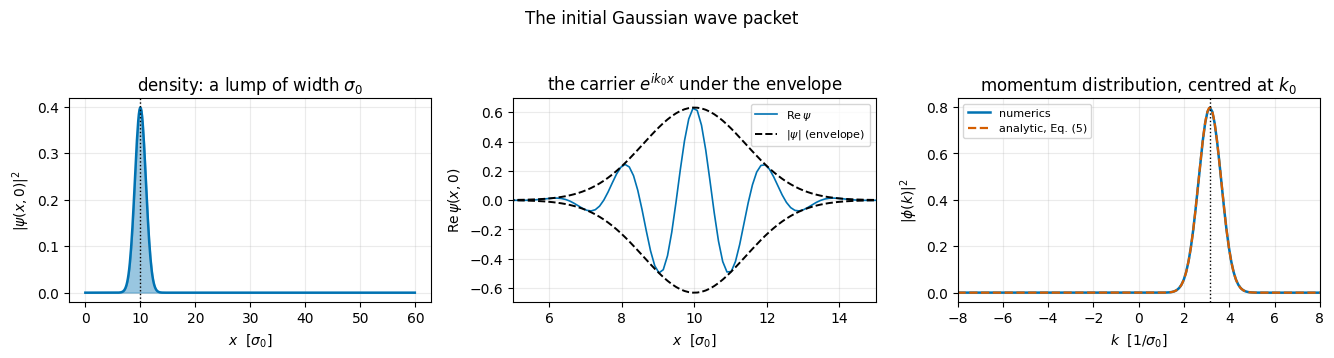

In [6]:
# ==============================================================================
# FIGURE: the initial state -- density, real part, and momentum distribution
# ==============================================================================
C_NUM, C_ANA, C_FD = "#0072B2", "#D55E00", "#009E73"      # colour-blind friendly: blue / orange / green

phi0 = np.fft.fft(psi0)                                    # coefficients of psi0 in the plane-wave basis
weights = np.abs(phi0) ** 2 / np.sum(np.abs(phi0) ** 2)    # normalised |phi(k)|^2 (the momentum distribution)
k_sorted = np.argsort(k)                                   # undo the wrapped ordering, for plotting only

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.4))

axes[0].fill_between(x, 0, np.abs(psi0) ** 2, color=C_NUM, alpha=0.4)
axes[0].plot(x, np.abs(psi0) ** 2, color=C_NUM, lw=1.8)
axes[0].axvline(X_C, color="k", ls=":", lw=1)
axes[0].set_xlabel(r"$x$  [$\sigma_0$]"), axes[0].set_ylabel(r"$|\psi(x,0)|^2$")
axes[0].set_title(r"density: a lump of width $\sigma_0$")

axes[1].plot(x, psi0.real, color=C_NUM, lw=1.2, label=r"$\mathrm{Re}\,\psi$")
axes[1].plot(x, np.abs(psi0), color="k", lw=1.4, ls="--", label=r"$|\psi|$ (envelope)")
axes[1].plot(x, -np.abs(psi0), color="k", lw=1.4, ls="--")
axes[1].set_xlim(X_C - 5, X_C + 5)
axes[1].set_xlabel(r"$x$  [$\sigma_0$]"), axes[1].set_ylabel(r"$\mathrm{Re}\,\psi(x,0)$")
axes[1].set_title(r"the carrier $e^{ik_0x}$ under the envelope")
axes[1].legend(fontsize=8, loc="upper right")

axes[2].plot(k[k_sorted], weights[k_sorted] / (2 * np.pi / L), color=C_NUM, lw=1.8, label="numerics")
k_fine = np.linspace(-8, 8, 400)
axes[2].plot(k_fine, np.exp(-2 * SIGMA0 ** 2 * (k_fine - K0) ** 2) / np.sqrt(np.pi / (2 * SIGMA0 ** 2)),
             color=C_ANA, ls="--", lw=1.6, label="analytic, Eq. (5)")
axes[2].axvline(K0, color="k", ls=":", lw=1)
axes[2].set_xlim(-8, 8)
axes[2].set_xlabel(r"$k$  [$1/\sigma_0$]"), axes[2].set_ylabel(r"$|\phi(k)|^2$")
axes[2].set_title(r"momentum distribution, centred at $k_0$")
axes[2].legend(fontsize=8)

for ax in axes:
    ax.grid(alpha=0.25)
fig.suptitle("The initial Gaussian wave packet", y=1.04)
fig.tight_layout()
plt.show()

**Left:** the probability density — a bump of width $\sigma_0 = 1$ at $x_c = 10$, and zero (to machine
precision) everywhere else, in particular at the seam. **Middle:** zoomed in, the real part of $\psi$ oscillates
under the Gaussian envelope with wavelength $2\pi/k_0 = 2$; this carrier is the momentum. **Right:** the
momentum distribution obtained from the FFT of the array, on top of the analytic Gaussian of Eq. (5) centred at
$k_0 = \pi$ with width $\sigma_k = 0.5$. The two curves lie on top of each other — our first
numerics-versus-analytics comparison, and the FFT has just passed its first test.

### 5.1 The two rules of Section 4.4, violated on purpose

**Rule 1: a non-commensurate $k_0$.** If $k_0 L/(2\pi)$ is not an integer, $e^{ik_0x}$ jumps at the seam. For our
narrow packet the wave function there is $\sim e^{-25}$, so nothing happens — but as soon as the packet is wide
enough to reach the boundary, the jump is a real discontinuity, and a discontinuity in $x$ means a fat tail in
$k$ ("spectral leakage") which the grid cannot represent. Let us make a deliberately wide packet and look.

**Rule 2: aliasing.** The grid cannot tell the mode index $m$ from $m + N_x$: the two sampled arrays are the
*same array*, because $e^{i2\pi(m+N_x)x_j/L} = e^{i2\pi m x_j/L}\,e^{2\pi i j}$ and $e^{2\pi ij}=1$. So the
grid always reports the index in the band, i.e. $m$ reduced modulo $N_x$ into $[-N_x/2, N_x/2)$. And that is
the trap: if we ask for $m$ with $N_x/2 < m < N_x$, the grid reads it as $m - N_x < 0$, and the packet we
think we kicked to the right calmly travels to the left. The next cell checks both statements on arrays.

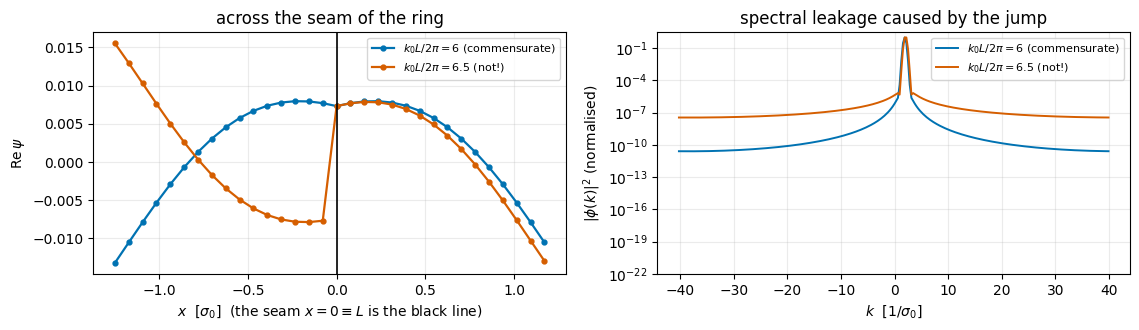

k0 for m =   236:   24.7139   (inside the band, |k| < pi/dx = 26.808)
k0 for m =   748:   78.3304   (far outside the band)
max |psi_a - psi_b| on the grid = 4.019e-14   <- the grid cannot tell them apart (this is round-off, the two arrays are the SAME function)

we ask for m = 296 -> k0 = +30.9970  (above Nyquist pi/dx = 26.808)
the grid stores m = -216 -> k0 = -22.6195  <- NEGATIVE: the packet will move LEFT
   max |psi(m=296) - psi(m=-216)| = 2.223e-14   (the same array)
   <k> read back from the array           = -22.6195   (not +30.9970!)


In [7]:
# ==============================================================================
# FAILURE DEMO 1: k0 not commensurate with the ring  ->  a jump at the seam
# FAILURE DEMO 2: k0 above the Nyquist limit         ->  aliasing (the packet turns around)
# ==============================================================================
# --- Demo 1: a wide packet (sigma = 2.5) on a small ring, with and without commensurate k0 ---
L_w, N_w = 20.0, 256
x_w, k_w, dx_w = make_grid(L_w, N_w)
psi_good = gaussian_packet(x_w, 0.5 * L_w, 2.5, 2.0 * np.pi * 6 / L_w)     # m = 6      (commensurate)
psi_bad = gaussian_packet(x_w, 0.5 * L_w, 2.5, 2.0 * np.pi * 6.5 / L_w)   # m = 6.5    (NOT commensurate)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))
for psi_c, lab, col, ls in ((psi_good, r"$k_0 L/2\pi = 6$ (commensurate)", C_NUM, "-"),
                            (psi_bad, r"$k_0 L/2\pi = 6.5$ (not!)", C_ANA, "-")):
    # roll the array so that the seam x = 0 == L sits in the middle of the picture
    axes[0].plot(np.concatenate([x_w - L_w, x_w])[N_w - 16:N_w + 16],
                 np.concatenate([psi_c.real, psi_c.real])[N_w - 16:N_w + 16], ls + "o", color=col, lw=1.6,
                 ms=3.5, label=lab)
    w = np.abs(np.fft.fft(psi_c)) ** 2
    axes[1].semilogy(k_w[np.argsort(k_w)], (w / w.max())[np.argsort(k_w)], color=col, lw=1.4, label=lab)
axes[0].axvline(0.0, color="k", lw=1.2)
axes[0].set_xlabel(r"$x$  [$\sigma_0$]  (the seam $x=0\equiv L$ is the black line)")
axes[0].set_ylabel(r"$\mathrm{Re}\,\psi$")
axes[0].set_title("across the seam of the ring")
axes[1].set_xlabel(r"$k$  [$1/\sigma_0$]"), axes[1].set_ylabel(r"$|\phi(k)|^2$ (normalised)")
axes[1].set_ylim(1e-22, 3), axes[1].set_title("spectral leakage caused by the jump")
for ax in axes:
    ax.grid(alpha=0.25), ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# --- Demo 2: aliasing is exact, not approximate ---
m_ok = N_X // 2 - 20                      # a legal mode index
m_alias = m_ok + N_X                      # the SAME grid function, N_x modes higher
psi_a = gaussian_packet(x, X_C, SIGMA0, 2.0 * np.pi * m_ok / L)
psi_b = gaussian_packet(x, X_C, SIGMA0, 2.0 * np.pi * m_alias / L)
print(f"k0 for m = {m_ok:5d}:  {2 * np.pi * m_ok / L:8.4f}   (inside the band, |k| < pi/dx = {np.pi / dx:.3f})")
print(f"k0 for m = {m_alias:5d}:  {2 * np.pi * m_alias / L:8.4f}   (far outside the band)")
print(f"max |psi_a - psi_b| on the grid = {np.max(np.abs(psi_a - psi_b)):.3e}"
      "   <- the grid cannot tell them apart (this is round-off, the two arrays are the SAME function)")
assert np.max(np.abs(psi_a - psi_b)) < 1e4 * TOL

# ... and the consequence: an index just ABOVE N_x/2 is read as a NEGATIVE one, i.e. as a kick to the LEFT
m_right = N_X // 2 + 40                   # we *think* we kick to the right with k0 = 2 pi m_right / L
m_seen = m_right - N_X                    # what the grid actually holds: a negative mode index
psi_r = gaussian_packet(x, X_C, SIGMA0, 2.0 * np.pi * m_right / L)
psi_l = gaussian_packet(x, X_C, SIGMA0, 2.0 * np.pi * m_seen / L)
w_r = np.abs(np.fft.fft(psi_r)) ** 2
print(f"\nwe ask for m = {m_right} -> k0 = {2 * np.pi * m_right / L:+8.4f}  (above Nyquist pi/dx = {np.pi / dx:.3f})")
print(f"the grid stores m = {m_seen} -> k0 = {2 * np.pi * m_seen / L:+8.4f}  <- NEGATIVE: the packet will move LEFT")
print(f"   max |psi(m={m_right}) - psi(m={m_seen})| = {np.max(np.abs(psi_r - psi_l)):.3e}   (the same array)")
print(f"   <k> read back from the array           = {np.sum(w_r * k) / np.sum(w_r):+8.4f}"
      f"   (not {2 * np.pi * m_right / L:+.4f}!)")
assert np.sum(w_r * k) / np.sum(w_r) < 0.0, "an over-Nyquist kick is read back as a negative momentum"

**Left panel:** the commensurate packet (blue) crosses the seam continuously; the non-commensurate one
(orange) **jumps** — the value coming back in at $x=0$ does not match the value leaving at $x=L$.

**Right panel:** a discontinuity in real space is a fat tail in Fourier space. This deliberately wide packet
($\sigma_0 = 2.5$ on a ring of only $L=20$) is not small at the seam either, so even the commensurate one has a
tail — its *slope* is discontinuous there, which gives $\vert\phi\vert^2 \sim k^{-4}$ and a floor near
$10^{-10}$ (blue). The non-commensurate packet has a jump in the *value*, which gives only
$\vert\phi\vert^2 \sim k^{-2}$ and a floor a thousand times higher (orange). Those components are not
physics; they are the seam, and at the edge of the band they get aliased. **Always choose $k_0 = 2\pi m/L$ with
integer $m$** — and keep the packet away from the seam, or accept that you are simulating a genuinely different
initial state.

**The aliasing print:** two wave numbers differing by $N_x$ modes give the *same* grid function — the printed
$10^{-14}$ is only the round-off of evaluating two different `exp` expressions, not a physical difference.
There is no approximation here and no warning message; the information is simply not on the grid. The second
half of the print makes the damage concrete: asking for the mode index $m = N_x/2 + 40$ stores the array of
$m - N_x = -216$, and reading the mean momentum back off that array returns a *negative* number. The packet
will move to the left. If you ever see a packet moving in the wrong direction, check $k_0$ against
$\pi/\Delta x$ first.

## 6. Method A — finite differences

We now need the second derivative of an array. This is the first genuinely *numerical* idea of the course.

### 6.1 Deriving the three-point Laplacian

Taylor-expand the exact function around $x_j$, in both directions, to fourth order:

$$ \begin{aligned}
   \psi(x_j+\Delta x) &= \psi_j + \Delta x\,\psi'_j + \tfrac{\Delta x^{2}}{2}\psi''_j
       + \tfrac{\Delta x^{3}}{6}\psi'''_j + \tfrac{\Delta x^{4}}{24}\psi''''_j + \ldots \\
   \psi(x_j-\Delta x) &= \psi_j - \Delta x\,\psi'_j + \tfrac{\Delta x^{2}}{2}\psi''_j
       - \tfrac{\Delta x^{3}}{6}\psi'''_j + \tfrac{\Delta x^{4}}{24}\psi''''_j - \ldots
   \end{aligned} $$

Add the two lines. The odd derivatives cancel, and

$$ \psi_{j+1} + \psi_{j-1} = 2\psi_j + \Delta x^{2}\psi''_j + \frac{\Delta x^{4}}{12}\psi''''_j + O(\Delta x^{6}) . $$

Solve for $\psi''_j$:

$$ \boxed{\;\psi''_j \;=\; \frac{\psi_{j+1} - 2\psi_j + \psi_{j-1}}{\Delta x^{2}}
   \;-\; \frac{\Delta x^{2}}{12}\psi''''_j + O(\Delta x^{4}) \;} \tag{9} $$

The first term is the **three-point Laplacian**; the rest is the **discretisation error**, which is
$O(\Delta x^2)$: the method is *second-order accurate*. Halving $\Delta x$ divides the error by four. That
prediction is testable, and we will test it.

On the ring, "$j+1$" for $j = N_x-1$ means $j=0$: the stencil **wraps around**. In NumPy this is one line,
`np.roll(psi, -1) - 2*psi + np.roll(psi, +1)`, with no loop and no special treatment of the edges.

### 6.2 The Hamiltonian is a circulant matrix

Writing $H = -\tfrac12 \partial_x^2$ with the stencil (9) gives a matrix acting on the vector
$(\psi_0,\ldots,\psi_{N_x-1})$:

$$ H_{jl} = \frac{1}{2\Delta x^{2}}\left(2\delta_{j,l} - \delta_{j,l+1} - \delta_{j,l-1}\right),
   \qquad \text{indices mod } N_x . $$

Every row is the previous row shifted by one — a **circulant** matrix. That single structural fact is the key to
everything in this section and the next, because of a classical theorem:

> **The eigenvectors of any circulant matrix are the plane waves** $v^{(n)}_j = e^{ik_nx_j}/\sqrt{N_x}$,
> whatever the entries are. Only the eigenvalues depend on them.

The reason is symmetry: a circulant matrix commutes with the shift $j \to j+1$, and the plane waves are the
eigenvectors of the shift. Let us find the eigenvalues by simply applying $H$ to a plane wave:

$$ \begin{aligned}
   \left(H v^{(n)}\right)_j &= \frac{1}{2\Delta x^{2}}
       \left(2 e^{ik_nx_j} - e^{ik_nx_{j+1}} - e^{ik_nx_{j-1}}\right) \frac{1}{\sqrt{N_x}} \\
   &= \frac{e^{ik_nx_j}}{2\Delta x^{2}\sqrt{N_x}}\left(2 - e^{ik_n\Delta x} - e^{-ik_n\Delta x}\right)
    = \frac{1 - \cos(k_n\Delta x)}{\Delta x^{2}}\; v^{(n)}_j ,
   \end{aligned} $$

using $e^{i\theta}+e^{-i\theta} = 2\cos\theta$. So the **discrete dispersion relation** is

$$ \boxed{\;\omega_{\rm FD}(k) \;=\; \frac{1-\cos(k\Delta x)}{\Delta x^{2}}\;}
   \qquad\text{versus the exact}\qquad \omega(k) = \frac{k^{2}}{2} . \tag{10} $$

Expand for small $k\Delta x$, using $\cos\theta = 1 - \theta^2/2 + \theta^4/24 - \ldots$:

$$ \omega_{\rm FD}(k) = \frac{k^{2}}{2} - \frac{k^{4}\Delta x^{2}}{24} + O(\Delta x^{4}) , $$

confirming the $O(\Delta x^2)$ accuracy of Eq. (9), and showing exactly *how* the discretisation lies: it makes
high-$k$ components **too slow**. The group velocity of the discretised theory is

$$ v_{\rm FD}(k) = \frac{d\omega_{\rm FD}}{dk} = \frac{\sin(k\Delta x)}{\Delta x} \;<\; k
   \qquad (0 < k \le \pi/\Delta x) , $$

since $\sin\theta<\theta$ for $\theta>0$. Worse than "too slow": $v_{\rm FD}$ is not even monotonic. It rises
to a maximum $1/\Delta x$ at $k\Delta x = \pi/2$ and then *falls back*, reaching exactly **zero** at the edge
of the band, $k\Delta x = \pi$. The fastest-oscillating grid modes — those with two points per wavelength —
do not propagate at all in the finite-difference model, although the true theory says they are the fastest
of all. (They are also exactly the modes the grid barely resolves, so the two failures arrive together.)

### 6.3 The exact propagator of the discretised Hamiltonian

Because we know all the eigenvectors and eigenvalues of $H_{\rm FD}$, we can apply $e^{-iH_{\rm FD}t}$ *exactly*,
with no time step and no time-integration error at all:

1. expand $\psi$ in plane waves (that is what the FFT does): $\phi_n = \mathrm{FFT}[\psi]_n$;
2. multiply each coefficient by $e^{-i\omega_{\rm FD}(k_n) t}$;
3. transform back with the inverse FFT.

This is a deliberate choice: it isolates the **spatial** discretisation error, which is what we want to study.
(Notebook 00b takes the other road — build the matrix, exponentiate it, or integrate the ODE in time — and
there you will meet the time-integration error as well.)

In [8]:
# ==============================================================================
# STEP 3: the finite-difference Hamiltonian as an explicit matrix (small N_x only!)
#   We build it once, for N_x = 8, to SEE the circulant structure and to CHECK
#   the eigenvalue formula (10).  For production we never build this matrix.
# ==============================================================================
def fd_hamiltonian_matrix(N_x, dx):
    """Dense matrix of H = -(1/2) d^2/dx^2 with the 3-point stencil and periodic wrap-around.

    MATH
        H[j,l] = (2 delta_{j,l} - delta_{j,l+1} - delta_{j,l-1}) / (2 dx^2),  indices modulo N_x
    COST
        N_x^2 memory -- this is a TEACHING function; the production code never forms H.
    """
    H = np.zeros((N_x, N_x))
    for j in range(N_x):
        H[j, j] = 2.0
        H[j, (j + 1) % N_x] = -1.0                 # the "% N_x" IS the periodic boundary condition
        H[j, (j - 1) % N_x] = -1.0
    return H / (2.0 * dx ** 2)


H_small = fd_hamiltonian_matrix(8, 1.0)            # dx = 1 so the numbers are readable
print("H for N_x = 8, dx = 1  (every row is the row above, shifted by one -> CIRCULANT):")
print(H_small)
print("\nnote the two entries in the corners: they connect site 7 to site 0 -- the ring closes here.")

# CHECKPOINT: the eigenvalues must be (1 - cos(k dx)) / dx^2 -- Eq. (10)
x8, k8, dx8 = make_grid(L=8.0, N_x=8)
eigenvalues_numeric = np.sort(np.linalg.eigvalsh(H_small))
eigenvalues_formula = np.sort((1.0 - np.cos(k8 * dx8)) / dx8 ** 2)
print(f"\neigenvalues from numpy  : {np.round(eigenvalues_numeric, 6)}")
print(f"eigenvalues from Eq.(10): {np.round(eigenvalues_formula, 6)}")
err_eig = float(np.max(np.abs(eigenvalues_numeric - eigenvalues_formula)))
print(f"max difference = {err_eig:.3e}")
assert err_eig < 1e4 * TOL
print("CHECKPOINT passed: plane waves really are the eigenvectors of the finite-difference Hamiltonian.")

H for N_x = 8, dx = 1  (every row is the row above, shifted by one -> CIRCULANT):
[[ 1.  -0.5  0.   0.   0.   0.   0.  -0.5]
 [-0.5  1.  -0.5  0.   0.   0.   0.   0. ]
 [ 0.  -0.5  1.  -0.5  0.   0.   0.   0. ]
 [ 0.   0.  -0.5  1.  -0.5  0.   0.   0. ]
 [ 0.   0.   0.  -0.5  1.  -0.5  0.   0. ]
 [ 0.   0.   0.   0.  -0.5  1.  -0.5  0. ]
 [ 0.   0.   0.   0.   0.  -0.5  1.  -0.5]
 [-0.5  0.   0.   0.   0.   0.  -0.5  1. ]]

note the two entries in the corners: they connect site 7 to site 0 -- the ring closes here.

eigenvalues from numpy  : [-0.        0.292893  0.292893  1.        1.        1.707107  1.707107
  2.      ]
eigenvalues from Eq.(10): [0.       0.292893 0.292893 1.       1.       1.707107 1.707107 2.      ]
max difference = 5.551e-16
CHECKPOINT passed: plane waves really are the eigenvectors of the finite-difference Hamiltonian.


The matrix is exactly as advertised: $2$ on the diagonal, $-1$ next to it, and — crucially — a $-1$ in the two
far corners, `H[0, 7]` and `H[7, 0]`, which is where the ring closes. Its eigenvalues agree with the closed-form
expression (10) to machine precision, which confirms the whole algebra of Section 6.2.

Now let us plot the two dispersion relations against each other. This single figure explains every
finite-difference error we will see later.

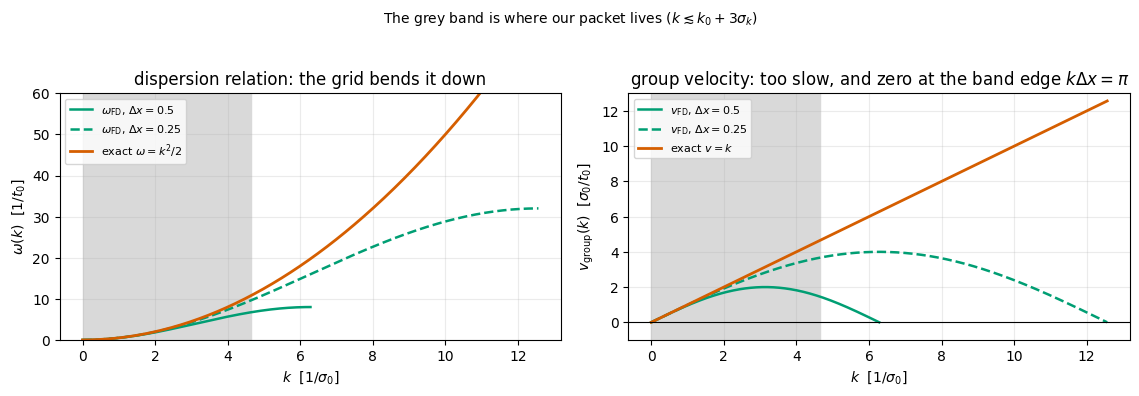

In [9]:
# ==============================================================================
# FIGURE: exact versus discrete dispersion relation, and the group velocities
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
for dx_test, style in ((0.5, "-"), (0.25, "--")):
    kk = np.linspace(0, np.pi / dx_test, 400)
    axes[0].plot(kk, (1 - np.cos(kk * dx_test)) / dx_test ** 2, style, color=C_FD, lw=1.8,
                 label=rf"$\omega_{{\rm FD}}$, $\Delta x = {dx_test}$")
    axes[1].plot(kk, np.sin(kk * dx_test) / dx_test, style, color=C_FD, lw=1.8,
                 label=rf"$v_{{\rm FD}}$, $\Delta x = {dx_test}$")
kk = np.linspace(0, np.pi / 0.25, 400)
axes[0].plot(kk, 0.5 * kk ** 2, color=C_ANA, lw=2.0, label=r"exact $\omega = k^2/2$")
axes[1].plot(kk, kk, color=C_ANA, lw=2.0, label=r"exact $v = k$")
axes[0].axvspan(0, K0 + 3 * SIGMA_K, color="0.85", zorder=0)
axes[1].axvspan(0, K0 + 3 * SIGMA_K, color="0.85", zorder=0)
axes[0].set_ylim(0, 60), axes[1].set_ylim(-1, 13)
axes[1].axhline(0.0, color="k", lw=0.8)
axes[0].set_xlabel(r"$k$  [$1/\sigma_0$]"), axes[0].set_ylabel(r"$\omega(k)$  [$1/t_0$]")
axes[0].set_title("dispersion relation: the grid bends it down")
axes[1].set_xlabel(r"$k$  [$1/\sigma_0$]"), axes[1].set_ylabel(r"$v_{\rm group}(k)$  [$\sigma_0/t_0$]")
axes[1].set_title(r"group velocity: too slow, and zero at the band edge $k\Delta x = \pi$")
for ax in axes:
    ax.grid(alpha=0.25), ax.legend(fontsize=8, loc="upper left")
fig.suptitle(r"The grey band is where our packet lives ($k \lesssim k_0 + 3\sigma_k$)", y=1.03, fontsize=10)
fig.tight_layout()
plt.show()

Inside the grey band — where our packet actually has weight — the discrete curves hug the exact ones, and they
hug them more closely for the finer grid: this is the $O(\Delta x^2)$ of Eq. (9), visible to the eye. Towards
the edge of the band the discretisation is simply a different physical theory: $\omega_{\rm FD}$ saturates at
$2/\Delta x^2$ instead of growing like $k^2$, and the group velocity, after peaking at $1/\Delta x$, comes
back down to zero. Note that each curve stops at its own Nyquist wave number $\pi/\Delta x$ — there is nothing
to plot beyond it, because the grid holds no such mode.

> **Common pitfall.** A "converged-looking" finite-difference simulation can still be wrong if the state
> develops structure on the scale of $\Delta x$ (sharp fronts, high-momentum components after hitting a
> barrier). The way to find out is never to look at one grid — it is to **run two grids and compare**.

## 7. Method B — the Fourier (spectral) method

Look again at Section 6.3: to apply $e^{-iH_{\rm FD}t}$ we went to Fourier space, multiplied by a phase, and
came back. But the *exact* Hamiltonian is diagonal in Fourier space too — that was Eq. (6)! So the very same
three steps, with $\omega_{\rm FD}$ replaced by the exact $\omega = k^2/2$, solve the *original* equation:

$$ \boxed{\;\psi(x,t) \;=\; \mathrm{IFFT}\Big[\,e^{-i k^{2}t/2}\;\mathrm{FFT}\big[\psi(x,0)\big]\Big] \;} \tag{11} $$

This is the **Fourier (spectral) method**, and it has remarkable properties:

* it is **exact in time** — Eq. (11) holds for any $t$, small or huge, with no time step at all;
* it is **spectrally accurate in space** — the only error is that the grid truncates the momentum band at
  $\pi/\Delta x$, i.e. it throws away $\vert\phi(k)\vert^2 \propto e^{-2\sigma_0^2(k-k_0)^2}$ for
  $\vert k\vert>\pi/\Delta x$. By Parseval the $L^2$ error is the square root of that discarded weight, so it
  falls like $e^{-\sigma_0^{2}\left(\pi/\Delta x - k_0\right)^{2}}$: **exponentially** in $1/\Delta x$, faster
  than any power. Compare with $O(\Delta x^2)$;
* it costs $O(N_x\log N_x)$ per application, thanks to the Fast Fourier Transform, versus $O(N_x^2)$ for a dense
  matrix-vector product and $O(N_x^3)$ for building a matrix exponential.

Everything rests on periodicity: the FFT *assumes* the array is one period of a periodic function. That is
exactly the ring, so we pay nothing.

### 7.1 One function for both methods

Both methods have the identical form "FFT, multiply by $e^{-i\omega(k)t}$, IFFT"; they differ only in the array
$\omega(k)$. So we write **one** propagator and feed it either dispersion relation. This is also our first JAX
code.

> **JAX practice.** `jax.jit` compiles a Python function once, for the given argument shapes, into a single
> optimised machine program, so the FFT, the multiplication and the inverse FFT run without Python overhead.
> `jax.vmap(f)` turns a function written for **one** input into one that handles a whole batch — here, all the
> snapshot times at once, without a Python loop. Both are explained properly in
> [01 — JAX from scratch](01_jax_from_scratch.ipynb); for now, read `jnp` as "NumPy".

In [10]:
# ==============================================================================
# STEP 4: THE propagator -- three lines that solve the Schrodinger equation
# ==============================================================================
@jax.jit
def propagate(psi, omega_k, t):
    """Exact evolution under any Hamiltonian that is diagonal in the plane-wave basis.

    MATH
        psi(t) = IFFT[ exp(-i omega(k) t) * FFT[psi(0)] ]
        omega(k) = k^2/2              -> the exact free Schrodinger equation      (spectral method)
        omega(k) = (1-cos(k dx))/dx^2 -> the 3-point finite-difference Hamiltonian (Eq. 10)
    IMPLEMENTATION
        psi and omega_k are arrays of shape (N_x,) in the SAME wrapped order as np.fft.fftfreq.
    COST
        O(N_x log N_x) per call, dominated by the two FFTs.  No time step: t may be any number.
    JAX
        jax.jit compiles the three operations into one program; t may be traced (a JAX scalar).
    """
    return jnp.fft.ifft(jnp.exp(-1j * omega_k * t) * jnp.fft.fft(psi))


# vmap over the LAST argument (t): one call -> a stack of snapshots, shape (n_times, N_x)
propagate_times = jax.jit(jax.vmap(propagate, in_axes=(None, None, 0)))

# the two dispersion relations, as arrays on our k-grid
omega_exact = jnp.asarray(0.5 * k ** 2, dtype=RDTYPE)                      # exact:  k^2/2
omega_fd = jnp.asarray((1.0 - np.cos(k * dx)) / dx ** 2, dtype=RDTYPE)     # 3-point stencil: Eq. (10)

psi0_j = jnp.asarray(psi0)                                                 # move the initial state to JAX
t_check = 3.0
psi_spec = np.asarray(propagate(psi0_j, omega_exact, t_check))
psi_fd = np.asarray(propagate(psi0_j, omega_fd, t_check))
psi_ana = psi_exact_line(x, t_check, X_C, SIGMA0, K0)

print(f"at t = {t_check}:")
print(f"  <x>  spectral = {mean_position(psi_spec, x, dx, L):.10f}   "
      f"FD = {mean_position(psi_fd, x, dx, L):.10f}   analytic = {X_C + K0 * t_check:.10f}")
print(f"  sigma spectral = {packet_width(psi_spec, x, dx, L):.10f}   "
      f"FD = {packet_width(psi_fd, x, dx, L):.10f}   analytic = "
      f"{SIGMA0 * np.sqrt(1 + (t_check / (2 * SIGMA0 ** 2)) ** 2):.10f}")
print(f"  max | |psi_spec|^2 - |psi_ana|^2 | = {np.max(np.abs(np.abs(psi_spec) ** 2 - np.abs(psi_ana) ** 2)):.3e}")
print(f"  max | |psi_fd|^2   - |psi_ana|^2 | = {np.max(np.abs(np.abs(psi_fd) ** 2 - np.abs(psi_ana) ** 2)):.3e}")

at t = 3.0:
  <x>  spectral = 19.4247779608   FD = 19.1977899526   analytic = 19.4247779608
  sigma spectral = 1.8027756377   FD = 1.7182432308   analytic = 1.8027756377
  max | |psi_spec|^2 - |psi_ana|^2 | = 3.101e-13
  max | |psi_fd|^2   - |psi_ana|^2 | = 1.896e-02


There it is: three lines of code, and the packet has moved by $k_0 t = 9.42$ and spread from $1$ to $1.80$,
both in agreement with Eq. (8). The spectral result matches the analytic density to $\sim 10^{-14}$ — machine
precision. The finite-difference result is visibly worse ($\sim 2\times10^{-2}$ in the density, and its
centre is already $0.23\,\sigma_0$ behind), and the reason is written in Eq. (10): its packet travels at the
wrong speed.

### 7.2 Checkpoint: the numerical group velocity of the finite-difference method

This is worth making quantitative, because it is a beautiful example of "the code is right, the *model* is
different". Since the momentum weights $\vert\phi(k)\vert^2$ never change, the mean position of the
finite-difference packet moves at the *weighted average* of the discrete group velocity:

$$ \langle x\rangle_{\rm FD}(t) = x_c + t \int \vert\phi(k)\vert^{2}\,\frac{\sin(k\Delta x)}{\Delta x}\, dk
   = x_c + t\,\frac{\sin(k_0\Delta x)}{\Delta x}\, e^{-\sigma_k^{2}\Delta x^{2}/2} , $$

where the last step is the standard Gaussian average
$\langle \sin(k\Delta x)\rangle = \sin(k_0\Delta x)\,e^{-\sigma_k^2\Delta x^2/2}$. Note that this says the
finite-difference packet moves *exactly linearly in time*, just at the wrong speed. We can measure that speed
and compare with the formula — a test of both the code and our understanding.

In [11]:
# ==============================================================================
# CHECKPOINT: measure the group velocity of each method and compare with theory
#   We use a DELIBERATELY COARSE grid so that the finite-difference error is big.
# ==============================================================================
N_coarse = 128                                       # dx = 60/128 = 0.469 -> a visible FD error
x_c_grid, k_c_grid, dx_c = make_grid(L, N_coarse)
psi0_c = jnp.asarray(gaussian_packet(x_c_grid, X_C, SIGMA0, K0))
omega_exact_c = jnp.asarray(0.5 * k_c_grid ** 2, dtype=RDTYPE)
omega_fd_c = jnp.asarray((1.0 - np.cos(k_c_grid * dx_c)) / dx_c ** 2, dtype=RDTYPE)

t_meas = np.linspace(0.0, 6.0, 25)
xbar = {}
for label, omega in (("spectral", omega_exact_c), ("finite differences", omega_fd_c)):
    snaps = np.asarray(propagate_times(psi0_c, omega, jnp.asarray(t_meas)))      # (25, N_coarse)
    # plain Riemann sum: legitimate here because the packet stays far from the seam at all these times
    xbar[label] = np.array([float(dx_c * np.sum(x_c_grid * np.abs(p) ** 2)) for p in snaps])

v_spec = np.polyfit(t_meas, xbar["spectral"], 1)[0]
v_fd = np.polyfit(t_meas, xbar["finite differences"], 1)[0]
# prediction: the weighted average of the discrete group velocity over the (frozen) momentum distribution
w_coarse = np.abs(np.fft.fft(np.asarray(psi0_c))) ** 2
w_coarse = w_coarse / np.sum(w_coarse)
v_fd_theory = float(np.sum(w_coarse * np.sin(k_c_grid * dx_c) / dx_c))
v_fd_closed = np.sin(K0 * dx_c) / dx_c * np.exp(-0.5 * SIGMA_K ** 2 * dx_c ** 2)   # Gaussian average, closed form

print(f"coarse grid: N_x = {N_coarse}, dx = {dx_c:.4f},  k0*dx = {K0 * dx_c:.4f} rad")
print(f"  exact group velocity            k0                        = {K0:.8f}")
print(f"  measured, spectral method                                 = {v_spec:.8f}")
print(f"  measured, finite differences                              = {v_fd:.8f}")
print(f"  predicted, sum_n w_n sin(k_n dx)/dx                       = {v_fd_theory:.8f}")
print(f"  same, in closed form: sin(k0 dx)/dx * exp(-sk^2 dx^2/2)   = {v_fd_closed:.8f}")
print(f"  the FD packet is too slow by {100 * (K0 - v_fd) / K0:.2f} %")
assert abs(v_spec - K0) < 1e5 * TOL, "the spectral method must reproduce the exact group velocity"
assert abs(v_fd - v_fd_theory) < 1e-9, "the FD velocity must match the discrete dispersion relation"
print("\nCHECKPOINT passed: both methods move at exactly the speed their own dispersion relation prescribes.")

coarse grid: N_x = 128, dx = 0.4688,  k0*dx = 1.4726 rad
  exact group velocity            k0                        = 3.14159265
  measured, spectral method                                 = 3.14159265
  measured, finite differences                              = 2.06554265
  predicted, sum_n w_n sin(k_n dx)/dx                       = 2.06554265
  same, in closed form: sin(k0 dx)/dx * exp(-sk^2 dx^2/2)   = 2.06554265
  the FD packet is too slow by 34.25 %

CHECKPOINT passed: both methods move at exactly the speed their own dispersion relation prescribes.


Read this carefully, because it is the most important lesson of the notebook. The finite-difference code is
**not buggy**. It solves *its own* equation — the one with dispersion $\omega_{\rm FD}$ — perfectly, to eight
decimal places. It is simply that its equation is not the Schrödinger equation; it is a $O(\Delta x^2)$
approximation to it, and on this coarse grid ($k_0\Delta x = 1.47$ radians per grid point, i.e. only
$2\pi/1.47 \approx 4.3$ points per wavelength) that approximation costs a third of the velocity.

The remedy is to refine the grid — and the *proof* that the remedy works is the convergence test. Before we run
it, let us extract from the simulation the numbers a physicist actually quotes: expectation values.

## 8. Expectation values, variances and Ehrenfest's theorem

A wave function is a lot of numbers. What an experiment reports is a handful of them: where the cloud is, how
wide it is, how fast it moves, how broad its velocity distribution is. Those are **expectation values** and
**variances**, and this section computes them three times — on paper, on the grid in position space, and on the
grid in momentum space — and puts the three on the same plot.

### 8.1 Definitions

For an observable represented by the operator $\hat A$ and a normalised state $\psi$,

$$ \langle A\rangle(t) \;=\; \int_{-\infty}^{\infty} \psi^{*}(x,t)\,\big(\hat A\,\psi\big)(x,t)\, dx ,
   \qquad \mathrm{Var}(A) \;=\; \langle A^{2}\rangle - \langle A\rangle^{2} . $$

We need two operators. Position acts by multiplication, $\hat x\,\psi(x) = x\,\psi(x)$. Momentum, in our
dimensionless units where $\hbar = 1$, is

$$ \hat p \;=\; -i\,\frac{\partial}{\partial x} , $$

which is the generator of translations and has the plane waves as eigenfunctions,
$\hat p\, e^{ikx} = k\, e^{ikx}$. The standard deviation of the position is what we called $\sigma(t)$:
$\mathrm{Var}(x) = \sigma^2(t)$.

One more quantity will turn out to be the mathematical incarnation of the chirp — the
**position-momentum covariance**. Because $\hat x$ and $\hat p$ do not commute, $\langle xp\rangle$ is not
real; the observable combination is the symmetrised one,

$$ C(t) \;=\; \tfrac12\big\langle \hat x\hat p + \hat p\hat x\big\rangle - \langle x\rangle\langle p\rangle . $$

### 8.2 Ehrenfest's theorem, derived

How does $\langle x\rangle$ change in time? Differentiate under the integral and use Eq. (2) in the form
$\partial_t\psi = \tfrac{i}{2}\partial_x^2\psi$ (and its complex conjugate
$\partial_t\psi^{*} = -\tfrac{i}{2}\partial_x^2\psi^{*}$):

$$ \frac{d\langle x\rangle}{dt} = \int \left[(\partial_t\psi^{*})\,x\,\psi + \psi^{*}x\,(\partial_t\psi)\right] dx
   = \frac{i}{2}\int\left[\psi^{*}x\,\partial_x^{2}\psi - (\partial_x^{2}\psi^{*})\,x\,\psi\right] dx . $$

Integrate the second term by parts twice. On a ring there are no boundary terms at all (everything is
periodic), and on the line they vanish because $\psi\to0$. Using
$\partial_x^2(x\psi) = x\,\partial_x^2\psi + 2\,\partial_x\psi$,

$$ \int (\partial_x^{2}\psi^{*})\, x\, \psi\, dx = \int \psi^{*}\,\partial_x^{2}(x\psi)\, dx
   = \int \psi^{*}\left(x\,\partial_x^{2}\psi + 2\,\partial_x\psi\right) dx . $$

The $x\,\partial_x^2\psi$ pieces cancel and we are left with

$$ \frac{d\langle x\rangle}{dt} = \frac{i}{2}\left(-2\int\psi^{*}\partial_x\psi\, dx\right)
   = \int \psi^{*}\left(-i\partial_x\right)\psi\, dx = \langle p\rangle . \tag{12} $$

For the momentum the argument is even shorter. The general rule, obtained the same way, is
$d\langle A\rangle/dt = i\langle[\hat H,\hat A]\rangle$ for a time-independent $\hat A$; with
$\hat H = \hat p^{2}/2$ we get

$$ \frac{d\langle p\rangle}{dt} = i\big\langle[\hat H,\hat p]\big\rangle = 0 , \tag{13} $$

because $\hat H$ is a function of $\hat p$ and commutes with it. (With a potential one finds the general
Ehrenfest theorem $d\langle p\rangle/dt = -\langle V'(x)\rangle$ — "force equals mass times acceleration" for
averages. Here $V \equiv 0$, so there is no force and the momentum is frozen. This is the road that notebook
00b takes.)

Equations (12) and (13) say: *the centre of the packet moves like a classical free particle*. Nothing about the
spreading — that lives in the variances.

### 8.3 The five numbers for our Gaussian packet

All of them can be read off the exact solution, Eq. (7), using the results of Section 3.5.

**Position.** The density is a Gaussian of centre $x_c + k_0t$ and standard deviation $\sigma(t)$, so

$$ \langle x\rangle(t) = x_c + k_0 t , \qquad
   \mathrm{Var}(x)(t) = \sigma^{2}(t) = \sigma_0^{2}\left(1+\frac{t^{2}}{4\sigma_0^{4}}\right)
   = \sigma_0^{2} + \frac{t^{2}}{4\sigma_0^{2}} . \tag{14} $$

**Momentum.** The momentum density $\vert\phi(k,t)\vert^{2} = \vert\phi(k,0)\vert^{2}$ is frozen (Section 3.3),
a Gaussian centred at $k_0$ with standard deviation $\sigma_k = 1/(2\sigma_0)$:

$$ \langle p\rangle(t) = k_0 = \text{const} , \qquad
   \mathrm{Var}(p)(t) = \sigma_k^{2} = \frac{1}{4\sigma_0^{2}} = \text{const} . \tag{15} $$

Physically: **no force, no change of momentum** — not of its average (that is Eq. (13)), and not even of its
distribution, because $\hat H$ and $\hat p$ commute so they share eigenstates and $\hat p$ is a constant of the
motion in the strongest possible sense.

**The ballistic law.** Combining (14) and (15),

$$ \boxed{\;\mathrm{Var}(x)(t) \;=\; \mathrm{Var}(x)(0) \;+\; \mathrm{Var}(p)\; t^{2}\;} \tag{16} $$

and this is *exactly* what a classical statistical ensemble would do: take a swarm of classical particles with
positions spread by $\sigma_0$ and velocities spread by $\sigma_k$, let each fly freely, $x_i(t) = x_i +
v_i t$; if positions and velocities are uncorrelated, the variances simply add,
$\mathrm{Var}(x)(t) = \mathrm{Var}(x)(0) + \mathrm{Var}(v)t^2$. The quantum packet spreads **ballistically**,
and it does so for the completely classical reason that it contains a range of velocities. What is *not*
classical is *why* it must contain them: the uncertainty relation forbids a localised state from having a sharp
momentum.

**The uncertainty product.** Multiplying (14) by (15),

$$ \mathrm{Var}(x)\,\mathrm{Var}(p) = \frac14 + \frac{t^{2}}{16\sigma_0^{4}} \;\ge\; \frac14 , \tag{17} $$

saturating the Heisenberg bound $\mathrm{Var}(x)\mathrm{Var}(p)\ge 1/4$ (i.e. $\sigma_x\sigma_p \ge \hbar/2$)
only at $t=0$. Free evolution destroys minimum uncertainty and never restores it.

**The covariance.** For a state written as $\vert\psi\vert e^{i\theta}$ one has
$\tfrac12\langle \hat x\hat p+\hat p\hat x\rangle = \int x\,\vert\psi\vert^{2}\,\theta'(x)\,dx$ (take the real
part of $\int\psi^{*}x(-i\partial_x)\psi$; the derivative of the modulus contributes only to the imaginary
part). With the chirped phase of Section 3.5(b), $\theta'(x) = k_{\rm loc} = k_0 + tX/(4\sigma_0^2\sigma^2(t))$
and $X = x - \langle x\rangle$,

$$ C(t) = \int X\,\vert\psi\vert^{2}\left(k_{\rm loc}-k_0\right) dx
   = \frac{t}{4\sigma_0^{2}\sigma^{2}(t)}\int X^{2}\vert\psi\vert^{2} dx
   = \frac{t}{4\sigma_0^{2}} = \mathrm{Var}(p)\, t . \tag{18} $$

So the covariance **is** the chirp: it measures how strongly "being ahead of the centre" correlates with
"moving fast". It starts at zero (the initial Gaussian is uncorrelated) and grows linearly. Consistently,
$d\,\mathrm{Var}(x)/dt = 2C(t)$, which you can check against Eq. (14) in one line.

### 8.4 Computing them on the grid: position

Straight from Section 4.2, replace each integral by a Riemann sum:

$$ \langle x\rangle \;\to\; \Delta x \sum_j x_j\,\vert\psi_j\vert^{2} , \qquad
   \langle x^{2}\rangle \;\to\; \Delta x \sum_j x_j^{2}\,\vert\psi_j\vert^{2} ,\qquad
   \mathrm{Var}(x) = \langle x^{2}\rangle - \langle x\rangle^{2} . $$

**A warning about the ring.** These formulas use the *coordinate* $x_j\in[0,L)$, which jumps from $L$ back to
$0$ at the seam. They are therefore only meaningful while the packet is far from the seam. Once it wraps
around, $\langle x\rangle$ in this naive sense is not merely inaccurate, it is *ill-defined*: on a circle there
is no such thing as "the average angle". The proper observable is the complex number
$\langle e^{2\pi ix/L}\rangle$, whose modulus measures how localised the state is on the ring and whose phase
gives the circular mean — exactly the quantity our `mean_position` function returns. In this section we stay
well before wrap-around ($t\le 6$, the packet never comes closer than nine standard deviations to the seam) and use the naive
sums, so that the comparison with the textbook formulas (14)–(18) is clean.

### 8.5 Computing them on the grid: momentum, two ways

**(a) In Fourier space.** Let $\phi_n = \sum_j \psi_j e^{-2\pi i jn/N_x}$ be the discrete Fourier transform
(this is what `np.fft.fft` computes) with inverse $\psi_j = \frac{1}{N_x}\sum_n \phi_n e^{2\pi i jn/N_x}$.
Substituting the inverse into a sum and exchanging the order of summation gives the **discrete Parseval
relation**:

$$ \sum_j \vert\psi_j\vert^{2}
   = \sum_j \psi_j^{*}\frac{1}{N_x}\sum_n \phi_n e^{2\pi i jn/N_x}
   = \frac{1}{N_x}\sum_n \phi_n \underbrace{\sum_j \psi_j^{*} e^{2\pi i jn/N_x}}_{=\;\phi_n^{*}}
   = \frac{1}{N_x}\sum_n \vert\phi_n\vert^{2} . $$

Since each $\phi_n$ multiplies the plane wave $e^{ik_nx_j}$, which is an eigenfunction of $\hat p$ with
eigenvalue $k_n$, the same manipulation with any function $f(\hat p)$ inserted gives

$$ \langle f(p)\rangle \;=\; \Delta x\sum_j \psi_j^{*}\big(f(\hat p)\psi\big)_j
   \;=\; \frac{\Delta x}{N_x}\sum_n f(k_n)\,\vert\phi_n\vert^{2}
   \;=\; \sum_n w_n\, f(k_n), \qquad w_n = \frac{\vert\phi_n\vert^{2}}{\sum_m \vert\phi_m\vert^{2}} , $$

where the last step used the normalisation. The weights $w_n$ are literally the momentum distribution of the
state, and $\langle p\rangle = \sum_n w_n k_n$, $\langle p^2\rangle = \sum_n w_n k_n^2$. All FFT normalisation
factors cancel in the ratio — which is why we wrote `momentum_weights` that way.

This is **exact** for a grid function (up to round-off): no approximation of the derivative is involved.

**(b) In position space with finite differences.** The textbook alternative is to discretise the derivative:

$$ \big(\hat p\,\psi\big)_j \approx -i\,\frac{\psi_{j+1}-\psi_{j-1}}{2\Delta x} , \qquad
   \big(\hat p^{2}\psi\big)_j \approx -\,\frac{\psi_{j+1}-2\psi_j+\psi_{j-1}}{\Delta x^{2}} , $$

with wrap-around indices, then $\langle p\rangle = \mathrm{Re}\left[\Delta x \sum_j \psi^{*}_j (\hat p\psi)_j\right]$.
Both stencils are $O(\Delta x^2)$ — the first follows from subtracting the two Taylor expansions of
Section 6.1 instead of adding them, the second is Eq. (9). Acting on a plane wave they give

$$ \hat p\,e^{ikx_j} \to \frac{\sin(k\Delta x)}{\Delta x}\,e^{ikx_j} , \qquad
   \hat p^{2} e^{ikx_j} \to \frac{2\big(1-\cos(k\Delta x)\big)}{\Delta x^{2}}\, e^{ikx_j} , $$

so we can *predict exactly* how wrong they will be:
$\langle p\rangle_{\rm FD} = \sum_n w_n \sin(k_n\Delta x)/\Delta x \approx k_0 - k_0^{3}\Delta x^{2}/6$.
Let us verify all of this.

In [12]:
# ==============================================================================
# STEP 5: expectation values and variances -- three implementations
#   (i) analytic formulas (14)-(18)
#   (ii) position-space Riemann sums / Fourier-space weights   [exact on the grid]
#   (iii) finite-difference derivatives                        [O(dx^2)]
# ==============================================================================
def momentum_weights(psi):
    """Normalised momentum distribution of a grid state -- the discrete Parseval relation of Section 8.5.

    MATH
        phi = FFT[psi];   w_n = |phi_n|^2 / sum_m |phi_m|^2   (all FFT normalisation factors cancel)
        <f(p)> = sum_n w_n f(k_n)   for any function of the momentum
    """
    w = np.abs(np.fft.fft(psi)) ** 2
    return w / np.sum(w)


def braket(psi, op_psi, dx):
    """<psi| A |psi> = dx * sum_j conj(psi_j) (A psi)_j, real part (all our operators are Hermitian)."""
    return float(np.real(dx * np.sum(np.conj(psi) * op_psi)))


def apply_p_spectral(psi, k):
    """p psi = -i d/dx psi, computed exactly on the grid:  IFFT[ k * FFT[psi] ]."""
    return np.fft.ifft(k * np.fft.fft(psi))


def apply_p_fd(psi, dx):
    """Central difference:  (p psi)_j = -i (psi_{j+1} - psi_{j-1}) / (2 dx),  indices mod N_x."""
    return -1j * (np.roll(psi, -1) - np.roll(psi, 1)) / (2.0 * dx)


def apply_p2_fd(psi, dx):
    """Three-point stencil: (p^2 psi)_j = -(psi_{j+1} - 2 psi_j + psi_{j-1}) / dx^2  -- Eq. (9)."""
    return -(np.roll(psi, -1) - 2.0 * psi + np.roll(psi, 1)) / dx ** 2


def observables(psi, x, k, dx):
    """All the numbers of Section 8, computed from one array.

    MATH
        <x>   = dx sum_j x_j |psi_j|^2                    <x^2> = dx sum_j x_j^2 |psi_j|^2
        <p>   = sum_n w_n k_n                             <p^2> = sum_n w_n k_n^2       (w = |phi|^2 normalised)
        C     = Re[ dx sum_j conj(psi_j) x_j (p psi)_j ] - <x><p>
    IMPLEMENTATION
        The position sums use the coordinate x_j in [0,L): valid only before the packet wraps around.
    """
    p_density = np.abs(psi) ** 2 * dx
    x1 = float(np.sum(p_density * x))
    x2 = float(np.sum(p_density * x ** 2))
    w = momentum_weights(psi)
    p1 = float(np.sum(w * k))
    p2 = float(np.sum(w * k ** 2))
    cov = braket(psi, x * apply_p_spectral(psi, k), dx) - x1 * p1
    return dict(x=x1, var_x=x2 - x1 ** 2, p=p1, var_p=p2 - p1 ** 2, cov=cov)


# ------------------------------------------------------------------------------
# Run the main packet and collect the observables at 41 times before wrap-around
# ------------------------------------------------------------------------------
T_EV = 6.0
t_ev = np.linspace(0.0, T_EV, 41)
snaps_ev = np.asarray(propagate_times(psi0_j, omega_exact, jnp.asarray(t_ev)))

obs = {key: np.array([observables(p, x, k, dx)[key] for p in snaps_ev])
       for key in ("x", "var_x", "p", "var_p", "cov")}

# the same momenta, but with the finite-difference operators
obs["p_fd"] = np.array([braket(p, apply_p_fd(p, dx), dx) for p in snaps_ev])
obs["p2_fd"] = np.array([braket(p, apply_p2_fd(p, dx), dx) for p in snaps_ev])
obs["var_p_fd"] = obs["p2_fd"] - obs["p_fd"] ** 2

# analytic references -- Eqs. (14)-(18)
ana = dict(x=X_C + K0 * t_ev,
           var_x=SIGMA0 ** 2 + t_ev ** 2 / (4.0 * SIGMA0 ** 2),
           p=np.full_like(t_ev, K0),
           var_p=np.full_like(t_ev, 1.0 / (4.0 * SIGMA0 ** 2)),
           cov=t_ev / (4.0 * SIGMA0 ** 2))
prod_num = obs["var_x"] * obs["var_p"]
prod_ana = 0.25 + t_ev ** 2 / (16.0 * SIGMA0 ** 4)

print(f"{'t':>5s} {'<x>':>10s} {'Var(x)':>10s} {'<p>':>10s} {'Var(p)':>10s} {'C':>10s} "
      f"{'Var(x)Var(p)':>13s} || {'<p> (FD)':>10s}")
for i in range(0, 41, 8):
    print(f"{t_ev[i]:5.2f} {obs['x'][i]:10.6f} {obs['var_x'][i]:10.6f} {obs['p'][i]:10.6f} "
          f"{obs['var_p'][i]:10.6f} {obs['cov'][i]:10.6f} {prod_num[i]:13.6f} || {obs['p_fd'][i]:10.6f}")

print("\nmaximal deviation from the analytic formulas, over all 41 times:")
for key, label in (("x", "<x>(t)   = x_c + k0 t              "),
                   ("var_x", "Var(x)(t)= sigma0^2 + t^2/(4 sigma0^2)"),
                   ("p", "<p>(t)   = k0                      "),
                   ("var_p", "Var(p)(t)= 1/(4 sigma0^2)          "),
                   ("cov", "C(t)     = t/(4 sigma0^2)          ")):
    err = float(np.max(np.abs(obs[key] - ana[key])))
    print(f"   {label}: {err:.3e}")
    assert err < 1e-9, f"{key} disagrees with the analytic result"
err_prod = float(np.max(np.abs(prod_num - prod_ana)))
print(f"   Var(x)Var(p) = 1/4 + t^2/(16 sigma0^4): {err_prod:.3e}")
assert err_prod < 1e-9
print(f"   uncertainty product at t=0: {prod_num[0]:.12f}  (Heisenberg minimum: 0.25)")

# ------------------------------------------------------------------------------
# The finite-difference momentum operators: wrong, but wrong in a PREDICTABLE way
# ------------------------------------------------------------------------------
w0 = momentum_weights(np.asarray(psi0_j))
p_fd_pred = float(np.sum(w0 * np.sin(k * dx) / dx))
p2_fd_pred = float(np.sum(w0 * 2.0 * (1.0 - np.cos(k * dx)) / dx ** 2))
print(f"\nmomentum from the SAME array, two ways (dx = {dx:.4f}, k0*dx = {K0 * dx:.4f}):")
print(f"   exact (Fourier)          <p> = {obs['p'][0]:.10f}   <p^2> = {float(np.sum(w0 * k ** 2)):.10f}")
print(f"   central difference       <p> = {obs['p_fd'][0]:.10f}   <p^2> = {obs['p2_fd'][0]:.10f}")
print(f"   predicted by the stencil <p> = {p_fd_pred:.10f}   <p^2> = {p2_fd_pred:.10f}")
print(f"   relative error of the finite-difference <p>: {abs(obs['p_fd'][0] - K0) / K0:.3e}"
      f"   (leading term k0^2 dx^2/6 = {K0 ** 2 * dx ** 2 / 6:.3e})")
print(f"   ... and the VARIANCE: exact {obs['var_p'][0]:.6f}  vs  finite differences {obs['var_p_fd'][0]:.6f}"
      f"   -> {100 * abs(obs['var_p_fd'][0] / obs['var_p'][0] - 1):.0f} % error!")
print(f"       (because Var(p) = {float(np.sum(w0 * k ** 2)):.4f} - {obs['p'][0] ** 2:.4f} is a small difference "
      "of two big numbers: a 1 % error in each is a 100 % error in the result)")
assert abs(obs["p_fd"][0] - p_fd_pred) < 1e-10 and abs(obs["p2_fd"][0] - p2_fd_pred) < 1e-10

# ------------------------------------------------------------------------------
# EHRENFEST, numerically: d<x>/dt must equal <p>, and d Var(x)/dt must equal 2 C
# ------------------------------------------------------------------------------
dt_ev = t_ev[1] - t_ev[0]
dxdt = (obs["x"][2:] - obs["x"][:-2]) / (2.0 * dt_ev)          # central difference in TIME
dvardt = (obs["var_x"][2:] - obs["var_x"][:-2]) / (2.0 * dt_ev)
err_ehrenfest = float(np.max(np.abs(dxdt - obs["p"][1:-1])))
err_var_rate = float(np.max(np.abs(dvardt - 2.0 * obs["cov"][1:-1])))
print(f"\nEhrenfest check   max |d<x>/dt - <p>|        = {err_ehrenfest:.3e}")
print(f"variance rate     max |dVar(x)/dt - 2 C(t)|  = {err_var_rate:.3e}")
print("   (both are exact to round-off here because <x>(t) is linear and Var(x)(t) quadratic in t,")
print("    so the central difference in time has no truncation error at all)")
assert err_ehrenfest < 1e-8 and err_var_rate < 1e-8
print("\nCHECKPOINT passed: every expectation value follows Eqs. (12)-(18).")

    t        <x>     Var(x)        <p>     Var(p)          C  Var(x)Var(p) ||   <p> (FD)
 0.00  10.000000   1.000000   3.141593   0.250000  -0.000000      0.250000 ||   3.065837
 1.20  13.769911   1.360000   3.141593   0.250000   0.300000      0.340000 ||   3.065837
 2.40  17.539822   2.440000   3.141593   0.250000   0.600000      0.610000 ||   3.065837
 3.60  21.309734   4.240000   3.141593   0.250000   0.900000      1.060000 ||   3.065837
 4.80  25.079645   6.760000   3.141593   0.250000   1.200000      1.690000 ||   3.065837
 6.00  28.849556  10.000000   3.141593   0.250000   1.500000      2.500000 ||   3.065837

maximal deviation from the analytic formulas, over all 41 times:
   <x>(t)   = x_c + k0 t              : 1.066e-14
   Var(x)(t)= sigma0^2 + t^2/(4 sigma0^2): 4.423e-13
   <p>(t)   = k0                      : 8.882e-16
   Var(p)(t)= 1/(4 sigma0^2)          : 5.329e-15
   C(t)     = t/(4 sigma0^2)          : 3.708e-14
   Var(x)Var(p) = 1/4 + t^2/(16 sigma0^4): 1.332e-13
   un

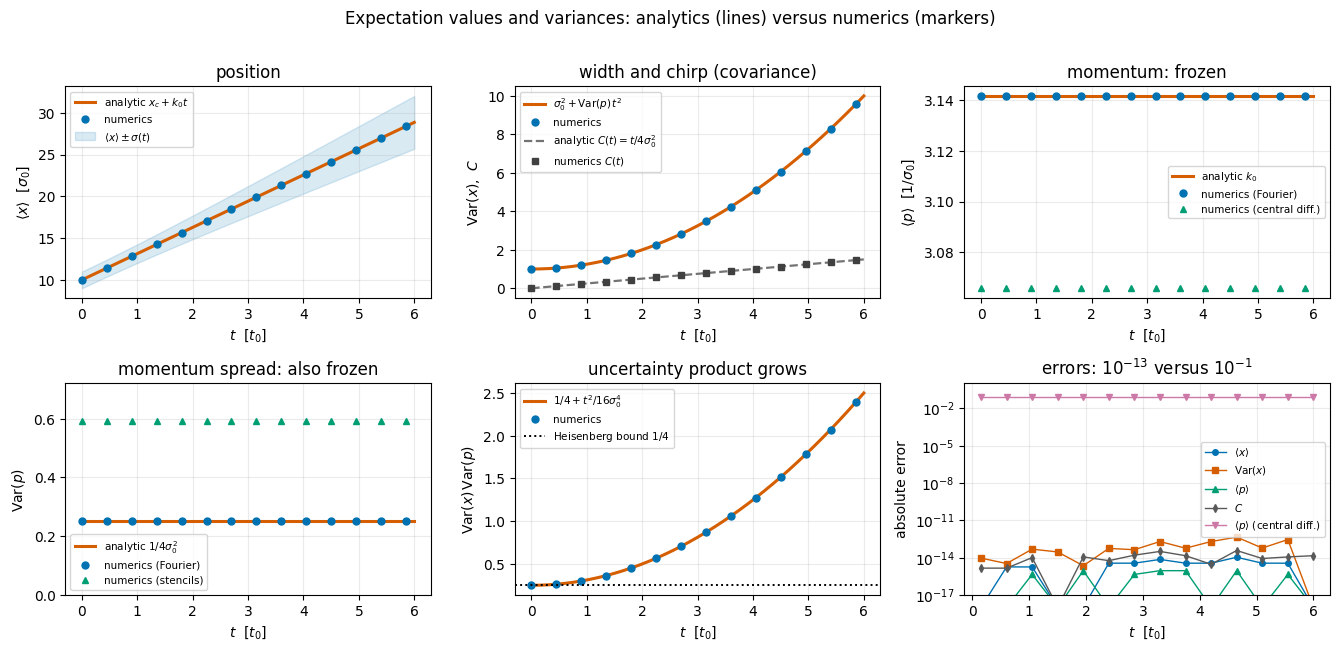

In [13]:
# ==============================================================================
# FIGURE: the five observables, numerics (markers) on top of analytics (lines)
# ==============================================================================
fig, axes = plt.subplots(2, 3, figsize=(13.5, 6.4))
ev = 3                                                   # plot every 3rd point, so the markers stay readable

axes[0, 0].plot(t_ev, ana["x"], color=C_ANA, lw=2.2, label=r"analytic $x_c + k_0t$")
axes[0, 0].plot(t_ev[::ev], obs["x"][::ev], "o", ms=5, color=C_NUM, label="numerics")
axes[0, 0].fill_between(t_ev, obs["x"] - np.sqrt(obs["var_x"]), obs["x"] + np.sqrt(obs["var_x"]),
                        color=C_NUM, alpha=0.15, label=r"$\langle x\rangle \pm \sigma(t)$")
axes[0, 0].set_ylabel(r"$\langle x\rangle$  [$\sigma_0$]"), axes[0, 0].set_title("position")

axes[0, 1].plot(t_ev, ana["var_x"], color=C_ANA, lw=2.2, label=r"$\sigma_0^2 + \mathrm{Var}(p)\,t^2$")
axes[0, 1].plot(t_ev[::ev], obs["var_x"][::ev], "o", ms=5, color=C_NUM, label="numerics")
axes[0, 1].plot(t_ev, ana["cov"], color="0.45", lw=1.6, ls="--", label=r"analytic $C(t) = t/4\sigma_0^2$")
axes[0, 1].plot(t_ev[::ev], obs["cov"][::ev], "s", ms=4, color="0.25", label=r"numerics $C(t)$")
axes[0, 1].set_ylabel(r"$\mathrm{Var}(x)$,  $C$"), axes[0, 1].set_title("width and chirp (covariance)")

axes[0, 2].plot(t_ev, ana["p"], color=C_ANA, lw=2.2, label=r"analytic $k_0$")
axes[0, 2].plot(t_ev[::ev], obs["p"][::ev], "o", ms=5, color=C_NUM, label="numerics (Fourier)")
axes[0, 2].plot(t_ev[::ev], obs["p_fd"][::ev], "^", ms=5, color=C_FD, label="numerics (central diff.)")
axes[0, 2].set_ylabel(r"$\langle p\rangle$  [$1/\sigma_0$]"), axes[0, 2].set_title("momentum: frozen")

axes[1, 0].plot(t_ev, ana["var_p"], color=C_ANA, lw=2.2, label=r"analytic $1/4\sigma_0^2$")
axes[1, 0].plot(t_ev[::ev], obs["var_p"][::ev], "o", ms=5, color=C_NUM, label="numerics (Fourier)")
axes[1, 0].plot(t_ev[::ev], obs["var_p_fd"][::ev], "^", ms=5, color=C_FD, label="numerics (stencils)")
axes[1, 0].set_ylim(0.0, 0.72)
axes[1, 0].set_ylabel(r"$\mathrm{Var}(p)$"), axes[1, 0].set_title("momentum spread: also frozen")

axes[1, 1].plot(t_ev, prod_ana, color=C_ANA, lw=2.2, label=r"$1/4 + t^2/16\sigma_0^4$")
axes[1, 1].plot(t_ev[::ev], prod_num[::ev], "o", ms=5, color=C_NUM, label="numerics")
axes[1, 1].axhline(0.25, color="k", ls=":", lw=1.4, label=r"Heisenberg bound $1/4$")
axes[1, 1].set_ylabel(r"$\mathrm{Var}(x)\,\mathrm{Var}(p)$"), axes[1, 1].set_title("uncertainty product grows")

for key, lab, col, mk in (("x", r"$\langle x\rangle$", C_NUM, "o"), ("var_x", r"$\mathrm{Var}(x)$", C_ANA, "s"),
                          ("p", r"$\langle p\rangle$", C_FD, "^"), ("cov", r"$C$", "0.35", "d")):
    axes[1, 2].semilogy(t_ev[1::ev], np.abs(obs[key] - ana[key])[1::ev] + 1e-18, mk + "-", ms=4, lw=1.0,
                        color=col, label=lab)
axes[1, 2].semilogy(t_ev[1::ev], np.abs(obs["p_fd"] - ana["p"])[1::ev], "v-", ms=4, lw=1.0, color="#CC79A7",
                    label=r"$\langle p\rangle$ (central diff.)")
axes[1, 2].set_ylabel("absolute error"), axes[1, 2].set_title(r"errors: $10^{-13}$ versus $10^{-1}$")
axes[1, 2].set_ylim(1e-17, 1)

for ax in axes.ravel():
    ax.set_xlabel(r"$t$  [$t_0$]"), ax.grid(alpha=0.25), ax.legend(fontsize=7.5)
fig.suptitle("Expectation values and variances: analytics (lines) versus numerics (markers)", y=1.01)
fig.tight_layout()
plt.show()

Panel by panel:

* **position** — the markers sit exactly on the straight line $x_c+k_0t$; the shaded band is
  $\langle x\rangle\pm\sigma(t)$ and shows the packet opening up like a funnel;
* **width and chirp** — $\mathrm{Var}(x)$ is the *parabola* of Eq. (16), not a straight line: the packet spreads
  ballistically, with the classical variance-addition law. The grey covariance $C(t)$ grows linearly, right on
  top of $t/(4\sigma_0^2)$: the chirp builds up at a constant rate;
* **momentum** — a flat line to thirteen digits. No force, no change. The green triangles are the *same
  physical state* measured with the central-difference operator: they sit visibly below, by
  $k_0^2\Delta x^2/6 \approx 2\times10^{-2}$ relative — a $2\%$ error on a grid that reproduces the density
  to $10^{-14}$;
* **momentum spread** — and here the finite-difference estimate is not $2\%$ wrong but $137\%$ wrong: the
  green triangles sit at $0.59$ where the answer is $0.25$, more than twice too large. Nothing new broke:
  $\mathrm{Var}(p) = \langle p^2\rangle - \langle p\rangle^2 = 10.12 - 9.87 = 0.25$ is a *small difference of
  two large numbers*, so a $1\%$ error in each of them is a $100\%$ error in the result. This is
  **catastrophic cancellation**, and it is the single most common way for a perfectly reasonable-looking
  program to produce nonsense;
* **uncertainty product** — starts exactly at the Heisenberg minimum $1/4$ and grows as $t^2$; the Gaussian is
  a minimum-uncertainty state for one instant only;
* **errors** — everything computed spectrally is at $10^{-13}$ or below (round-off); the finite-difference
  momentum is stuck at $10^{-1}$, flat in time, because it is a *systematic* error of the operator, not an
  accumulation.

> **Numerical practice.** An operator and a propagator are separate approximations. Here we propagated
> *exactly* and then measured with a second-order derivative: the result is a $2\%$ error in
> $\langle p\rangle$ on top of a machine-precision wave function. When you report an expectation value, ask
> which discretisation *it* used — not only which one the time evolution used.

> **Physics insight.** Equations (15)–(16) contain the entire physics of a time-of-flight measurement. After a
> long expansion, $\mathrm{Var}(x)(t)\to\mathrm{Var}(p)\,t^{2}$: the *shape of the cloud you photograph becomes
> a picture of its initial momentum distribution*, magnified by $t$. This is how the momentum distribution of a
> Bose-Einstein condensate is measured, and it is the same formula we just verified to thirteen digits.

## 9. The verdict: convergence, conservation, cost

### 9.1 The reference we compare against

One subtlety first. Our simulation lives on a ring; the analytic formula (7) is for an infinite line. They are
not the same problem. The exact solution on the ring is obtained by the **method of images**: sum the
infinite-line solution over all copies of the packet shifted by multiples of $L$,

$$ \psi_{\rm ring}(x,t) \;=\; \sum_{n=-\infty}^{\infty} \psi_{\rm line}(x + nL,\, t) . \tag{19} $$

Why this is correct: each term solves Eq. (2) (the equation is invariant under translations), the sum is
manifestly $L$-periodic, and at $t=0$ it reduces to the periodised initial condition — which, for a packet
narrow compared to $L$, is our initial array to machine precision. In practice a handful of images suffices;
the rest are astronomically small.

If instead we compared with the infinite-line formula alone, we would see an error **floor** at the level of the
tail of the packet at the seam — not a defect of the method, but of the reference. We will plot both, because
seeing that floor once teaches you to ask "what am I comparing against?" for the rest of your life.

### 9.2 How to read a convergence plot

We take a fixed time $t$, run the simulation on grids of increasing $N_x$ (decreasing $\Delta x$), and measure

$$ \mathrm{err}(\Delta x) \;=\; \left(\Delta x \sum_j \left\vert \psi^{\rm num}_j - \psi^{\rm exact}(x_j)\right\vert^{2}\right)^{1/2} , $$

the $L^2$ distance between the computed and the exact wave function (a dimensionless number between $0$ and
$2$, since both are normalised). We plot it against $\Delta x$ with **logarithmic axes on both sides**. The
reason: a power law $\mathrm{err} = C\,\Delta x^{\,p}$ becomes

$$ \log(\mathrm{err}) = \log C + p\,\log(\Delta x) , $$

a **straight line whose slope is the order $p$ of the method**. So on a log-log plot you do not admire the
curve, you *measure its slope* and compare it with the theoretical prediction — here $p=2$ from Eq. (9). A
method with an error that falls faster than any power (the spectral method) does not give a straight line at
all: it falls off a cliff and then flattens out on the round-off floor at $10^{-15}$, where it can go no
further.

In [14]:
# ==============================================================================
# STEP 6: the convergence test -- the single most important cell of this notebook
# ==============================================================================
def psi_exact_ring(x, t, x_c, sigma0, k0, L, n_images=6):
    """Exact solution on the RING, by the method of images -- Eq. (19).

    MATH
        psi_ring(x,t) = sum_{n=-n_images}^{n_images} psi_line(x + n L, t)
    IMPLEMENTATION
        Terms beyond |n| ~ (spread of the packet)/L are smaller than machine precision and are dropped.
    """
    out = np.zeros_like(x, dtype=CDTYPE)
    for n in range(-n_images, n_images + 1):
        out = out + psi_exact_line(x + n * L, t, x_c, sigma0, k0)
    return out


def l2_error(psi_num, psi_ref, dx):
    """L2 distance between two wave functions: sqrt( dx * sum_j |psi_num_j - psi_ref_j|^2 )."""
    return float(np.sqrt(dx * np.sum(np.abs(psi_num - psi_ref) ** 2)))


T_CONV = 6.0                     # time at which the comparison is made
X_C_CONV = 20.0                  # start further from the seam, so the "infinite line" reference is decent
M0_CONV = 10                     # gentler kick, so that even coarse grids are not aliased
K0_CONV = 2.0 * np.pi * M0_CONV / L

grids = [64, 96, 128, 192, 256, 384, 512, 768, 1024]
rows = []
for N in grids:
    xg, kg, dxg = make_grid(L, N)
    psi_start = jnp.asarray(gaussian_packet(xg, X_C_CONV, SIGMA0, K0_CONV))
    w_exact = jnp.asarray(0.5 * kg ** 2, dtype=RDTYPE)
    w_fd = jnp.asarray((1.0 - np.cos(kg * dxg)) / dxg ** 2, dtype=RDTYPE)
    ref_ring = psi_exact_ring(xg, T_CONV, X_C_CONV, SIGMA0, K0_CONV, L)
    ref_line = psi_exact_line(xg, T_CONV, X_C_CONV, SIGMA0, K0_CONV)
    p_spec = np.asarray(propagate(psi_start, w_exact, T_CONV))
    p_fd = np.asarray(propagate(psi_start, w_fd, T_CONV))
    rows.append((N, dxg, l2_error(p_fd, ref_ring, dxg), l2_error(p_spec, ref_ring, dxg),
                 l2_error(p_spec, ref_line, dxg),
                 abs(mean_position(p_fd, xg, dxg, L) - (X_C_CONV + K0_CONV * T_CONV)),
                 abs(mean_position(p_spec, xg, dxg, L) - (X_C_CONV + K0_CONV * T_CONV))))

print(f"{'N_x':>5s} {'dx':>9s} {'err FD':>11s} {'err Fourier':>12s} {'err F. (line ref)':>18s} "
      f"{'|d<x>| FD':>11s} {'|d<x>| F.':>11s}")
for r in rows:
    print(f"{r[0]:5d} {r[1]:9.5f} {r[2]:11.3e} {r[3]:12.3e} {r[4]:18.3e} {r[5]:11.3e} {r[6]:11.3e}")

# fitted order of the finite-difference method, using only the well-resolved grids
dxs = np.array([r[1] for r in rows])
err_fd_arr = np.array([r[2] for r in rows])
err_sp_arr = np.array([r[3] for r in rows])
fit = np.polyfit(np.log(dxs[4:]), np.log(err_fd_arr[4:]), 1)   # only N_x >= 256: no aliasing left
print(f"\nfitted slope of the FD error on the log-log plot: p = {fit[0]:.4f}   (theory: p = 2)")
assert 1.9 < fit[0] < 2.1, "the 3-point Laplacian must converge at second order"
assert err_sp_arr[-1] < 1e4 * TOL, "the Fourier method must reach machine precision"
print("CHECKPOINT passed: second-order convergence for finite differences, machine precision for Fourier.")

  N_x        dx      err FD  err Fourier  err F. (line ref)   |d<x>| FD   |d<x>| F.
   64   0.93750   7.318e-01    1.795e-03          1.795e-03   1.505e+00   2.800e-05
   96   0.62500   4.526e-01    7.927e-10          4.253e-09   7.043e-01   3.553e-15
  128   0.46875   2.882e-01    2.849e-15          4.864e-09   4.022e-01   3.553e-15
  192   0.31250   1.380e-01    2.194e-15          5.499e-09   1.804e-01   3.553e-15
  256   0.23438   7.903e-02    1.815e-15          5.831e-09   1.018e-01   3.553e-15
  384   0.15625   3.545e-02    1.965e-15          6.172e-09   4.532e-02   3.553e-15
  512   0.11719   1.999e-02    1.951e-15          6.345e-09   2.551e-02   3.553e-15
  768   0.07812   8.898e-03    2.010e-15          6.520e-09   1.134e-02   3.553e-15
 1024   0.05859   5.007e-03    1.941e-15          6.608e-09   6.382e-03   3.553e-15

fitted slope of the FD error on the log-log plot: p = 1.9909   (theory: p = 2)
CHECKPOINT passed: second-order convergence for finite differences, machine prec

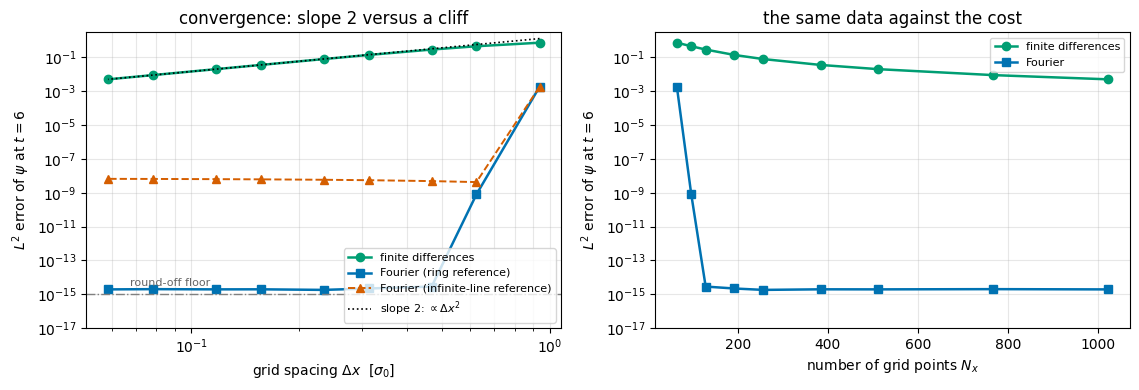

In [15]:
# ==============================================================================
# FIGURE: the convergence plot
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))

axes[0].loglog(dxs, err_fd_arr, "o-", color=C_FD, lw=1.8, label="finite differences")
axes[0].loglog(dxs, err_sp_arr, "s-", color=C_NUM, lw=1.8, label="Fourier (ring reference)")
axes[0].loglog(dxs, [r[4] for r in rows], "^--", color=C_ANA, lw=1.4,
               label="Fourier (infinite-line reference)")
ref = err_fd_arr[-1] * (dxs / dxs[-1]) ** 2
axes[0].loglog(dxs, ref, "k:", lw=1.2, label=r"slope 2: $\propto \Delta x^2$")
axes[0].axhline(1e-15, color="0.5", lw=1, ls="-.")
axes[0].text(dxs[-1] * 1.15, 3.0e-15, "round-off floor", fontsize=8, color="0.4")
axes[0].set_xlabel(r"grid spacing $\Delta x$  [$\sigma_0$]")
axes[0].set_ylabel(r"$L^2$ error of $\psi$ at $t=6$")
axes[0].set_title("convergence: slope 2 versus a cliff")
axes[0].set_ylim(1e-17, 3)

axes[1].semilogy([r[0] for r in rows], err_fd_arr, "o-", color=C_FD, lw=1.8, label="finite differences")
axes[1].semilogy([r[0] for r in rows], err_sp_arr, "s-", color=C_NUM, lw=1.8, label="Fourier")
axes[1].set_xlabel(r"number of grid points $N_x$")
axes[1].set_ylabel(r"$L^2$ error of $\psi$ at $t=6$")
axes[1].set_title("the same data against the cost")
axes[1].set_ylim(1e-17, 3)

for ax in axes:
    ax.grid(alpha=0.3, which="both"), ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**This plot is the whole scientific method in one picture.**

* The green finite-difference points fall on a straight line of slope $2$ (the dotted guide). Fitted over the
  well-resolved grids ($N_x \ge 256$) the slope is $p = 1.99$ — precisely what the Taylor expansion (9)
  predicted, and the small deficit is the next term of the expansion, $O(\Delta x^4)$. The method works, and we
  now *know* it works, rather than hoping so.
* The blue Fourier points do not lie on a line at all. From $\Delta x = 0.94$ to $\Delta x = 0.47$ the error
  drops from $1.8\times10^{-3}$ to $2.8\times10^{-15}$ — twelve orders of magnitude for a factor of two in
  $\Delta x$ — and then it stops at $\sim 10^{-15}$: there is nothing left to compute, the
  answer is exact to double precision. That is **spectral accuracy**, and it is the reason the Fourier method
  dominates this field.
* The orange curve is the same Fourier calculation compared with the *infinite-line* formula. It flattens out
  at $\sim 10^{-8}$ — not because the method fails, but because at $t=6$ the tail of the packet has reached the
  seam at the $10^{-8}$ level and the ring is genuinely a different system. **The error you measure is only as
  good as the reference you measure it against.**
* Right panel: at $N_x = 128$ the Fourier method is already **fourteen** orders of magnitude better than
  finite differences ($2.8\times10^{-15}$ against $2.9\times10^{-1}$), for the same memory and essentially the
  same run time. To match that with the three-point stencil you would have to shrink $\Delta x$ by
  $\sqrt{2.9\times10^{-1}/2.8\times10^{-15}} \approx 10^{7}$ — that is $\sim 10^{9}$ grid points, which no
  computer will hold, and long before you got there the round-off floor would stop you anyway.

### 9.3 Conservation laws: the checks you can run without an exact solution

The exact solution is a luxury. In every realistic simulation you do not have one, and the conserved quantities
become your main diagnostic. For a free particle these are the norm (probability is not created or destroyed),
the mean momentum and the energy (there is no force). Let us verify all three along the main run.

In [16]:
# ==============================================================================
# STEP 7: conservation checks -- norm, <k>, <E>
# ==============================================================================
def mean_k(psi, k):
    """<k> = sum_n w_n k_n   with w = normalised |phi(k)|^2."""
    return float(np.sum(momentum_weights(psi) * k))


def mean_energy(psi, omega_k):
    """<E> = sum_n w_n omega(k_n)  -- the energy OF THE MODEL that omega_k describes."""
    return float(np.sum(momentum_weights(psi) * np.asarray(omega_k)))


t_grid = np.linspace(0.0, T_MAX, 9)
snaps_spec = np.asarray(propagate_times(psi0_j, omega_exact, jnp.asarray(t_grid)))
snaps_fd = np.asarray(propagate_times(psi0_j, omega_fd, jnp.asarray(t_grid)))

print(f"{'t':>5s} | {'norm-1':>11s} {'<k>-k0':>11s} {'<E>-E(0)':>11s} | {'<x> err':>10s} {'sigma err':>10s} "
      f"|| {'FD <x> err':>11s} {'FD sig err':>11s}")
E0_spec = mean_energy(snaps_spec[0], omega_exact)
for i, t in enumerate(t_grid):
    ps, pf = snaps_spec[i], snaps_fd[i]
    sigma_ana = SIGMA0 * np.sqrt(1 + (t / (2 * SIGMA0 ** 2)) ** 2)
    print(f"{t:5.2f} | {norm_riemann(ps, dx) - 1:11.3e} {mean_k(ps, k) - K0:11.3e} "
          f"{mean_energy(ps, omega_exact) - E0_spec:11.3e} | "
          f"{abs(mean_position(ps, x, dx, L) - (X_C + K0 * t)):10.3e} "
          f"{abs(packet_width(ps, x, dx, L) - sigma_ana):10.3e} || "
          f"{abs(mean_position(pf, x, dx, L) - (X_C + K0 * t)):11.3e} "
          f"{abs(packet_width(pf, x, dx, L) - sigma_ana):11.3e}")

# CHECKPOINT: conservation and agreement with Eq. (8)
for i, t in enumerate(t_grid):
    sigma_ana = SIGMA0 * np.sqrt(1 + (t / (2 * SIGMA0 ** 2)) ** 2)
    assert abs(norm_riemann(snaps_spec[i], dx) - 1.0) < 1e4 * TOL
    assert abs(mean_k(snaps_spec[i], k) - K0) < 1e4 * TOL
    assert abs(mean_position(snaps_spec[i], x, dx, L) - (X_C + K0 * t)) < 1e-9
    assert abs(packet_width(snaps_spec[i], x, dx, L) - sigma_ana) < 1e-9
print("\nCHECKPOINT passed: norm, <k> and <E> conserved; <x>(t) and sigma(t) match Eq. (8) to ~1e-12.")

    t |      norm-1      <k>-k0    <E>-E(0) |    <x> err  sigma err ||  FD <x> err  FD sig err
 0.00 |  -2.220e-16   0.000e+00   0.000e+00 |  1.776e-15  0.000e+00 ||   1.776e-15   0.000e+00
 1.00 |   2.220e-16   0.000e+00   8.882e-16 |  1.776e-15  2.220e-16 ||   7.576e-02   1.489e-02
 2.00 |  -2.220e-16  -4.441e-16  -8.882e-16 |  3.553e-15  6.661e-16 ||   1.515e-01   4.757e-02
 3.00 |   0.000e+00  -8.882e-16   0.000e+00 |  0.000e+00  4.441e-16 ||   2.270e-01   8.453e-02
 4.00 |   0.000e+00   0.000e+00   8.882e-16 |  7.105e-15  0.000e+00 ||   3.023e-01   1.216e-01
 5.00 |  -2.220e-16  -8.882e-16   0.000e+00 |  3.553e-15  4.441e-16 ||   3.773e-01   1.582e-01
 6.00 |   0.000e+00   0.000e+00   8.882e-16 |  0.000e+00  8.882e-16 ||   4.520e-01   1.942e-01
 7.00 |   0.000e+00   0.000e+00   8.882e-16 |  3.553e-15  1.332e-15 ||   5.261e-01   2.298e-01
 8.00 |   0.000e+00  -8.882e-16   0.000e+00 |  7.105e-15  2.554e-12 ||   5.998e-01   2.652e-01

CHECKPOINT passed: norm, <k> and <E> conserved; <

Every conserved quantity is conserved to $10^{-14}$ or better, and the spectral $\langle x\rangle(t)$ and
$\sigma(t)$ follow Eq. (8) to twelve digits, while the finite-difference values drift away. The two drifts
have two different causes, and both are predicted by Eq. (10):

* the **centre** lags behind *exactly linearly in time*, $\Delta v\cdot t$, with
  $\Delta v = k_0 - \sin(k_0\Delta x)e^{-\sigma_k^2\Delta x^2/2}/\Delta x = 0.0758$ — and indeed the table
  shows $0.0758$ at $t=1$ and $0.5998 \approx 8\times 0.0758$ at $t=8$;
* the **width** grows too slowly for a different reason: spreading is governed by the *curvature* of the
  dispersion relation, and $\omega''_{\rm FD}(k_0) = \cos(k_0\Delta x) = 0.933 < 1 = \omega''(k_0)$. Replacing
  $\tau = t/(2\sigma_0^2)$ by $0.933\,\tau$ in Eq. (8) gives $\sigma_{\rm FD}(8) = 3.864$ against the exact
  $4.123$, a deficit of $0.259$ — compare the $0.2652$ in the table; the same estimate reproduces the whole
  column ($0.015, 0.047, 0.119, 0.259$ at $t=1,2,4,8$) to a few per cent. Note that this deficit is *not*
  linear in $t$; it only becomes so once $\tau\gg1$.

Two honest remarks about these checks:

* The norm, $\langle k\rangle$ and $\langle E\rangle$ are conserved **by construction** here: our propagator
  multiplies each Fourier coefficient by a pure phase, which cannot change $\vert\phi(k)\vert$. So these checks
  cannot detect a wrong dispersion relation — but they *do* catch the most common implementation bugs (a wrong
  `fftfreq` scaling, a missing $2\pi$, an `fft`/`ifft` normalisation mix-up), and they are the *only* checks you
  will have in notebook 00b once a potential makes the Hamiltonian non-diagonal in $k$. Run them always.
* The agreement of $\langle x\rangle$ and $\sigma$ with Eq. (8) is a genuinely independent test: nothing in the
  code knows about Eq. (8).

### 9.4 Cost: why nobody builds the matrix

Finally, the practical argument. There are three ways to apply $e^{-iHt}$ to a vector of length $N_x$:
diagonalise $H$ ($O(N_x^3)$, and $O(N_x^2)$ memory), multiply by the resulting dense propagator ($O(N_x^2)$),
or do two FFTs ($O(N_x\log N_x)$). Let us measure.

In [17]:
# ==============================================================================
# PERFORMANCE: building a dense propagator (O(N^3)) versus two FFTs (O(N log N))
#   Timings on a shared laptop CPU fluctuate; what matters is how they SCALE with N_x.
# ==============================================================================
def best_of(fn, n_calls=200, n_batches=8):
    """Median-free honest timing: run n_calls, repeat n_batches times, keep the FASTEST batch."""
    best = np.inf
    for _ in range(n_batches):
        t0 = time.perf_counter()
        for _ in range(n_calls):
            fn()
        best = min(best, (time.perf_counter() - t0) / n_calls)
    return best


print(f"{'N_x':>6s} {'eigh(H) [ms]':>14s} {'2 x FFT [ms]':>14s} {'ratio':>10s}   "
      f"{'N_x^3':>10s} {'N_x log2 N_x':>13s}")
for N in (128, 256, 512):
    xg, kg, dxg = make_grid(L, N)
    psi_g = jnp.asarray(gaussian_packet(xg, X_C, SIGMA0, K0))
    w_g = jnp.asarray(0.5 * kg ** 2, dtype=RDTYPE)

    H = fd_hamiltonian_matrix(N, dxg)
    t0 = time.perf_counter()
    evals, evecs = np.linalg.eigh(H)                      # O(N^3): diagonalise once
    t_eigh = time.perf_counter() - t0

    _ = propagate(psi_g, w_g, 1.0).block_until_ready()    # compile FIRST, then time
    t_fft = best_of(lambda: propagate(psi_g, w_g, 1.0).block_until_ready())

    print(f"{N:6d} {1e3 * t_eigh:14.3f} {1e3 * t_fft:14.4f} {t_eigh / t_fft:9.0f}x   "
          f"{N ** 3:10d} {N * np.log2(N):13.0f}")

   N_x   eigh(H) [ms]   2 x FFT [ms]      ratio        N_x^3  N_x log2 N_x


   128          2.495         0.0726        34x      2097152           896


   256         14.908         0.1307       114x     16777216          2048


   512         89.793         0.1235       727x    134217728          4608


Diagonalising the $N_x\times N_x$ matrix costs **three to four and a half orders of magnitude** more than one
propagation step (read the `ratio` column of your own run; the exact value depends on the machine),
and the gap widens with $N_x$: the operation count is $N_x^3 = 1.3\times10^{8}$ at $N_x=512$ against
$N_x\log_2 N_x = 4.6\times10^{3}$ for the two FFTs — a factor of $30\,000$, right there in the last two columns
of the table. Applying an already-built dense propagator is cheaper, $O(N_x^2)$ per state, but still far above
$O(N_x\log N_x)$, and it needs $N_x^2$ numbers of memory instead of $N_x$.

(Absolute timings on a laptop that is doing other things fluctuate by tens of percent, and the sub-millisecond
FFT timings are partly Python call overhead. Read the *scaling*, not the individual numbers — and when you
report a benchmark, say on what machine and under what load you measured it.)

The same argument, with far more violent numbers, is why the rest of this course never builds a Hamiltonian
matrix for a many-body system: there the vector length is $2^{20}$ and up, and $N^2$ is simply not storable.

> **Numerical practice.** "Matrix-free" is the guiding principle of the whole course: never store an operator as
> a matrix if you can write down how it *acts* on a state. Here the action is "multiply the Fourier
> coefficients"; in the many-body notebooks it will be "contract one tensor index".

## 10. Animations: watching the wave function move

Static snapshots do not do justice to quantum dynamics. We now write **one reusable function** that takes a
stack of curves (one per time) and produces an animated GIF embedded directly in the notebook.

How it works, step by step:

1. `matplotlib.animation.FuncAnimation` calls an `update(i)` function once per frame; `update` changes the data
   of the existing artists instead of redrawing the whole figure.
2. `PillowWriter` encodes the frames as an animated GIF.
3. We write that GIF to a **temporary file**, read the bytes back, and let the temporary directory delete
   itself — a notebook must never leave files behind.
4. We hand the bytes to `IPython.display` **twice, in one output**: once as a plain `image/gif`, and once as
   an `<img src="data:image/gif;base64,...">` HTML tag. A notebook output may carry several representations of
   the same thing, and each viewer picks the one it understands best — this is how the animation survives
   Jupyter, the Quarto website and the GitHub notebook viewer alike, with no extra files and no JavaScript.
5. `plt.close(fig)` prevents the last frame from also being displayed as a static figure.

Keep GIFs small: few frames, modest resolution. We print the size of each one.

In [18]:
# ==============================================================================
# STEP 8: a reusable "make an animated GIF from a stack of curves" function
# ==============================================================================
import base64
import tempfile

from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import display


def make_density_gif(x, densities, times, overlay=None, mean_x=None, envelope=None, band=None,
                     title="", ylabel=r"$|\psi(x,t)|^2$", ylim=None, fill=True,
                     label_num="numerics", label_ana="analytic",
                     fps=12, dpi=72, figsize=(7.0, 3.3)):
    """Animate a stack of curves and embed the result as an animated GIF in the notebook.

    ARGUMENTS
        x          : (N_x,)            the grid
        densities  : (n_frames, N_x)   the quantity to draw as a filled curve (usually |psi|^2)
        times      : (n_frames,)       the time of each frame, for the label
        overlay    : (n_frames, N_x)   optional reference curve, drawn dashed (usually the analytic solution)
        mean_x     : (n_frames,)       optional marker on the x-axis (usually <x>(t))
        envelope   : (n_frames, N_x)   optional thin grey curves at +/- envelope (used for Re psi)
        band       : (n_frames, 2)     optional horizontal bar [x_lo, x_hi] (usually <x> +/- sqrt(Var x))
    IMPLEMENTATION
        FuncAnimation -> PillowWriter -> a temporary file -> bytes -> one display() carrying BOTH
        an "image/gif" and a base64 "<img>" text/html representation of the same animation.
        The temporary directory removes itself, so the notebook writes nothing to disk.
        The figure is closed so that the last frame does not appear a second time as a static image.
    """
    densities = np.asarray(densities)
    n_frames = len(times)
    if ylim is None:
        lo, hi = float(densities.min()), float(densities.max())
        pad = 0.12 * (hi - lo)
        ylim = (lo - pad, hi + pad)

    fig, ax = plt.subplots(figsize=figsize)
    patch = ax.fill_between(x, 0, densities[0], color=C_NUM, alpha=0.35, lw=0) if fill else None
    (line_num,) = ax.plot(x, densities[0], color=C_NUM, lw=1.9, label=label_num)
    line_ana = ax.plot(x, overlay[0], color=C_ANA, lw=1.8, ls="--", label=label_ana)[0] if overlay is not None else None
    if envelope is not None:
        (line_env_p,) = ax.plot(x, envelope[0], color="0.45", lw=0.9)
        (line_env_m,) = ax.plot(x, -envelope[0], color="0.45", lw=0.9)
    bar = ax.plot(band[0], [ylim[0], ylim[0]], color="k", lw=2.5, solid_capstyle="butt",
                  clip_on=False, label=r"$\langle x\rangle \pm \sigma(t)$")[0] if band is not None else None
    marker = ax.plot([mean_x[0]], [ylim[0]], marker="^", ms=9, color="k",
                     clip_on=False, ls="none", label=r"$\langle x\rangle(t)$")[0] if mean_x is not None else None
    txt = ax.text(0.015, 0.90, "", transform=ax.transAxes, fontsize=11,
                  bbox=dict(boxstyle="round", fc="w", ec="0.7", alpha=0.85))
    ax.set_xlim(x[0], x[-1] + (x[1] - x[0])), ax.set_ylim(*ylim)
    ax.set_xlabel(r"$x$  [$\sigma_0$]"), ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
    fig.tight_layout()                                    # otherwise the x-label is cut off in the GIF

    def update(i):
        nonlocal patch
        if patch is not None:
            patch.remove()                                # a filled area cannot be updated: redraw it
            patch = ax.fill_between(x, 0, densities[i], color=C_NUM, alpha=0.35, lw=0)
        line_num.set_ydata(densities[i])
        if line_ana is not None:
            line_ana.set_ydata(overlay[i])
        if envelope is not None:
            line_env_p.set_ydata(envelope[i]), line_env_m.set_ydata(-envelope[i])
        if bar is not None:
            bar.set_data(band[i], [ylim[0], ylim[0]])
        if marker is not None:
            marker.set_data([mean_x[i]], [ylim[0]])
        txt.set_text(f"$t = {times[i]:5.2f}\\,t_0$")
        return ()

    anim = FuncAnimation(fig, update, frames=n_frames, interval=1000 / fps, blit=False)
    with tempfile.TemporaryDirectory() as tmpdir:         # the directory (and the GIF) vanish afterwards
        path = os.path.join(tmpdir, "anim.gif")
        anim.save(path, writer=PillowWriter(fps=fps), dpi=dpi)
        with open(path, "rb") as fh:
            gif_bytes = fh.read()
    plt.close(fig)                                        # no duplicate static image
    b64 = base64.b64encode(gif_bytes).decode("ascii")
    tag = f'<img src="data:image/gif;base64,{b64}" alt="animation" style="max-width:100%;height:auto">'
    display({"image/gif": b64, "text/html": tag}, raw=True)   # two representations, one output
    print(f"   [{n_frames} frames, {len(gif_bytes) / 1e6:.2f} MB embedded in the notebook]")


print("make_density_gif is ready.")

make_density_gif is ready.


### 10.1 Animation 1 — a packet at rest, spreading

Set $k_0 = 0$ and put the packet in the middle of the ring. Nothing moves; the lump just melts. The dashed
orange curve is Eq. (7) — watch it stay glued to the numerics.

max |numerics - analytic| over all frames: 2.776e-16


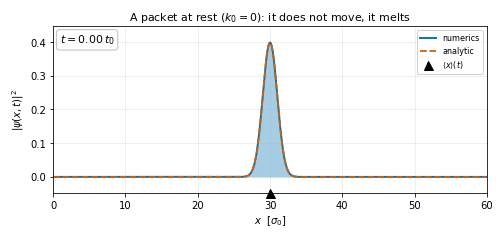

   [48 frames, 0.27 MB embedded in the notebook]


In [19]:
# ==============================================================================
# ANIMATION 1: k0 = 0 -- pure spreading, numerics versus Eq. (7)
# ==============================================================================
N_FRAMES = 48
t_frames = np.linspace(0.0, T_MAX, N_FRAMES)

psi0_rest = jnp.asarray(gaussian_packet(x, 0.5 * L, SIGMA0, 0.0))
snaps_rest = np.asarray(propagate_times(psi0_rest, omega_exact, jnp.asarray(t_frames)))
dens_rest = np.abs(snaps_rest) ** 2
dens_rest_ana = np.abs(np.stack([psi_exact_ring(x, t, 0.5 * L, SIGMA0, 0.0, L) for t in t_frames])) ** 2
xbar_rest = np.array([mean_position(p, x, dx, L) for p in snaps_rest])

print(f"max |numerics - analytic| over all frames: {np.max(np.abs(dens_rest - dens_rest_ana)):.3e}")
assert np.max(np.abs(dens_rest - dens_rest_ana)) < 1e4 * TOL

make_density_gif(x, dens_rest, t_frames, overlay=dens_rest_ana, mean_x=xbar_rest,
                 title=r"A packet at rest ($k_0=0$): it does not move, it melts")

The centre stays put — $\langle x\rangle$ is conserved because $\langle p \rangle = 0$ — and the width grows by
Eq. (8), from $\sigma_0=1$ to $\sigma = \sqrt{1+16} \approx 4.12$ at $t=8$. The peak height falls like
$1/\sigma(t)$ because the area under the curve is fixed at $1$. The numerics and the analytic curve are
indistinguishable, and the assert above says they agree to $3\times10^{-16}$ — round-off.

**This is what "a quantum particle at rest" looks like.** A classical particle at rest stays a point forever; a
quantum particle cannot even be at rest, because being localised means having a spread of momenta.

### 10.2 Animation 2 — kick it

Now $k_0 = \pi$. The lump moves to the right at velocity $k_0$ *and* spreads at the same time. The black
triangle marks the computed $\langle x\rangle(t)$ and slides at constant speed; the black bar it sits on is
$\langle x\rangle \pm \sigma(t)$, the two quantities of Section 8, and you can watch it lengthen as
$\sqrt{\mathrm{Var}(x)(0) + \mathrm{Var}(p)t^2}$.

max |numerics - analytic| over all frames: 3.668e-13
measured group velocity = 3.14159265   (exact: k0 = 3.14159265)


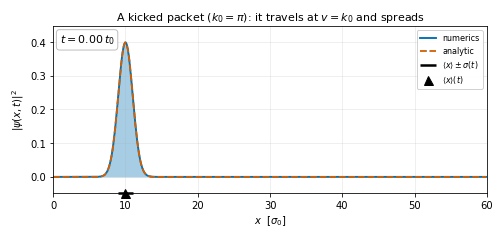

   [48 frames, 0.26 MB embedded in the notebook]


In [20]:
# ==============================================================================
# ANIMATION 2: k0 = pi -- motion at the group velocity, plus spreading
# ==============================================================================
snaps_move = np.asarray(propagate_times(psi0_j, omega_exact, jnp.asarray(t_frames)))
dens_move = np.abs(snaps_move) ** 2
dens_move_ana = np.abs(np.stack([psi_exact_ring(x, t, X_C, SIGMA0, K0, L) for t in t_frames])) ** 2
xbar_move = np.array([mean_position(p, x, dx, L) for p in snaps_move])
sig_move = np.array([packet_width(p, x, dx, L) for p in snaps_move])
band_move = np.stack([xbar_move - sig_move, xbar_move + sig_move], axis=1)   # <x> +/- sigma(t)

err_move = float(np.max(np.abs(dens_move - dens_move_ana)))
print(f"max |numerics - analytic| over all frames: {err_move:.3e}")
print(f"measured group velocity = {np.polyfit(t_frames, xbar_move, 1)[0]:.8f}   (exact: k0 = {K0:.8f})")
assert err_move < 1e4 * TOL

make_density_gif(x, dens_move, t_frames, overlay=dens_move_ana, mean_x=xbar_move, band=band_move,
                 title=r"A kicked packet ($k_0=\pi$): it travels at $v=k_0$ and spreads")

### 10.3 Animation 3 — the carrier wave and the chirp

The density hides half of the physics: it is blind to the phase. Here is $\mathrm{Re}\,\psi(x,t)$ with the
envelope $\pm\vert\psi\vert$ drawn in grey. Two things to watch:

* the individual crests move at the **phase velocity** $k_0/2$, i.e. half as fast as the envelope, so they
  continuously slip backwards through the lump and vanish at its rear;
* as time goes on, the oscillations become **visibly stretched at the back and compressed at the front** —
  the chirp of Section 3.5(b), $k_{\rm loc} = k_0 + X/t$: the fast components have run ahead.

The dashed orange curve is again the exact solution on the ring. In the last frames the wavelength at the
front of the packet is only a handful of pixels wide, so the two curves can *look* as if they had drifted
apart; the assert printed just below the animation shows that they agree to round-off everywhere. When an
animation is too coarse to prove a claim, prove it with a number — that is what the next figure does.

max |Re psi numerics - Re psi image sum| over all frames: 4.540e-12


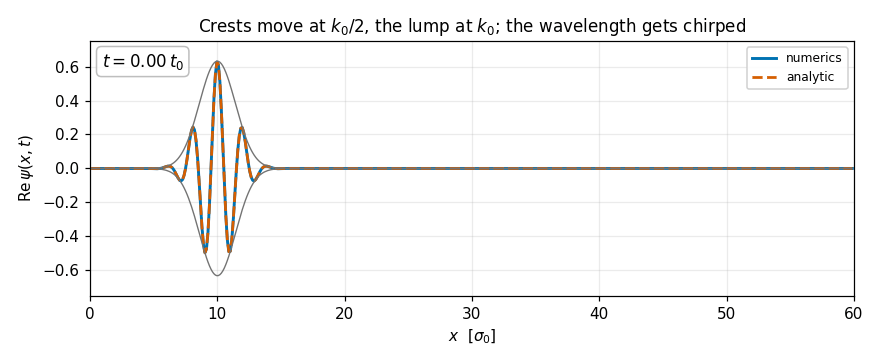

   [40 frames, 0.72 MB embedded in the notebook]


In [21]:
# ==============================================================================
# ANIMATION 3: Re psi -- phase velocity k0/2 versus group velocity k0, and the chirp
# ==============================================================================
t_chirp = np.linspace(0.0, 10.0, 40)
snaps_chirp = np.asarray(propagate_times(psi0_j, omega_exact, jnp.asarray(t_chirp)))
re_chirp = snaps_chirp.real
re_chirp_ana = np.stack([psi_exact_ring(x, t, X_C, SIGMA0, K0, L).real for t in t_chirp])
env_chirp = np.abs(snaps_chirp)

# CHECKPOINT first: the two curves really do coincide, even where the GIF cannot resolve them
err_chirp_frames = float(np.max(np.abs(re_chirp - re_chirp_ana)))
print(f"max |Re psi numerics - Re psi image sum| over all frames: {err_chirp_frames:.3e}")
assert err_chirp_frames < 1e4 * TOL

make_density_gif(x, re_chirp, t_chirp, overlay=re_chirp_ana, envelope=env_chirp, fill=False,
                 ylabel=r"$\mathrm{Re}\,\psi(x,t)$", ylim=(-0.75, 0.75), dpi=110, figsize=(8.0, 3.3),
                 title=r"Crests move at $k_0/2$, the lump at $k_0$; the wavelength gets chirped")

t = 6.0: sigma(t) = 3.1623,  local wave number varies from 1.679 to 4.615 across the packet (k_0 = 3.142)
max |k_loc numerical - k_loc analytic| where |psi|^2 > 1e-3 : 8.327e-11


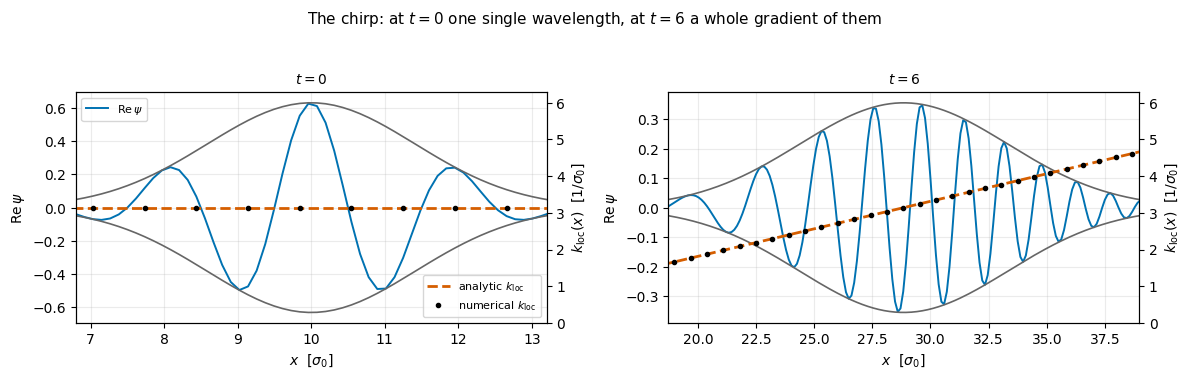

In [22]:
# ==============================================================================
# FIGURE + CHECKPOINT: the chirp, measured
#   The LOCAL wave number is the gradient of the phase.  With psi = |psi| exp(i theta),
#       d(psi)/dx / psi = d(ln|psi|)/dx + i theta'(x)   ->   k_loc = Im[ (d psi/dx) / psi ].
#   Analytic prediction (Section 3.5b):  k_loc = k0 + t X / (4 sigma0^2 sigma(t)^2).
# ==============================================================================
t_ch = 6.0            # late enough for a strong chirp, early enough to stay far from the seam
psi_ch = np.asarray(propagate(psi0_j, omega_exact, t_ch))
dpsi_ch = np.fft.ifft(1j * k * np.fft.fft(psi_ch))            # spectral derivative: exact on the grid
k_loc_num = np.imag(dpsi_ch / psi_ch)

sigma_t = SIGMA0 * np.sqrt(1 + (t_ch / (2 * SIGMA0 ** 2)) ** 2)
X_ch = x - X_C - K0 * t_ch
k_loc_ana = K0 + t_ch * X_ch / (4.0 * SIGMA0 ** 2 * sigma_t ** 2)

core = np.abs(psi_ch) ** 2 > 1e-3                             # only where the packet actually is
err_chirp = float(np.max(np.abs(k_loc_num[core] - k_loc_ana[core])))
print(f"t = {t_ch}: sigma(t) = {sigma_t:.4f},  local wave number varies from "
      f"{k_loc_num[core].min():.3f} to {k_loc_num[core].max():.3f} across the packet (k_0 = {K0:.3f})")
print(f"max |k_loc numerical - k_loc analytic| where |psi|^2 > 1e-3 : {err_chirp:.3e}")
assert err_chirp < 1e-9

fig, axes = plt.subplots(1, 2, figsize=(12.0, 3.6))
for ax, t_s in zip(axes, (0.0, t_ch)):
    p_s = np.asarray(propagate(psi0_j, omega_exact, t_s))
    c = X_C + K0 * t_s
    ax.plot(x, p_s.real, color=C_NUM, lw=1.4, label=r"$\mathrm{Re}\,\psi$")
    ax.plot(x, np.abs(p_s), color="0.4", lw=1.2), ax.plot(x, -np.abs(p_s), color="0.4", lw=1.2)
    ax.set_xlim(c - 3.2 * max(SIGMA0, SIGMA0 * np.sqrt(1 + (t_s / 2) ** 2)),
                c + 3.2 * max(SIGMA0, SIGMA0 * np.sqrt(1 + (t_s / 2) ** 2)))
    ax2 = ax.twinx()
    ax2.plot(x, k_loc_ana if t_s > 0 else np.full_like(x, K0), color=C_ANA, lw=2.0, ls="--",
             label=r"analytic $k_{\rm loc}$")
    ax2.plot(x[::6], (k_loc_num if t_s > 0 else np.full_like(x, K0))[::6], "o", ms=3, color="k",
             label=r"numerical $k_{\rm loc}$")
    ax2.set_ylim(0, 2 * K0), ax2.set_ylabel(r"$k_{\rm loc}(x)$  [$1/\sigma_0$]")
    ax.set_xlabel(r"$x$  [$\sigma_0$]"), ax.set_ylabel(r"$\mathrm{Re}\,\psi$")
    ax.set_title(rf"$t = {t_s:g}$", fontsize=10), ax.grid(alpha=0.25)
    if t_s == 0:
        ax.legend(fontsize=8, loc="upper left"), ax2.legend(fontsize=8, loc="lower right")
fig.suptitle(r"The chirp: at $t=0$ one single wavelength, at $t=6$ a whole gradient of them", y=1.04, fontsize=11)
fig.tight_layout()
plt.show()

At $t = 0$ the packet is a single wavelength $2\pi/k_0$ under a Gaussian envelope, and the local wave number
(black dots, right-hand axis) is the constant $k_0$. At $t = 6$ the oscillations are visibly stretched at the
back and compressed at the front, and $k_{\rm loc}(x)$ is a *straight line* rising through $k_0$ at the centre
of the packet — the slow components at the rear, the fast ones in front. The dashed orange line is the analytic
prediction of Section 3.5(b), and the assert says the two agree to $8\times10^{-11}$ wherever the packet has
any weight. (Why not $10^{-15}$? Because $k_{\rm loc} = \mathrm{Im}[\psi'/\psi]$ *divides* by $\psi$, and at
the $\vert\psi\vert^2 = 10^{-3}$ edge of the mask that amplifies the round-off of $\psi$ by $\sim 10^{2}$.)

This linear-in-$x$ local momentum is precisely the "runners sorted by speed" picture, and it is the reason the
covariance $C(t)$ of Section 8 is non-zero.

### 10.4 A space-time map, and a static fallback

Animations are wonderful but they cannot be read quantitatively, and some viewers do not play GIFs. Two
standard alternatives, which we will use throughout the course:

* a **space-time heat map** of $\vert\psi(x,t)\vert^2$, with $x$ horizontal and $t$ vertical: the trajectory of
  the packet becomes a straight line whose slope is $1/k_0$, and the spreading becomes a widening cone;
* a **static multi-panel figure** with a few snapshots.

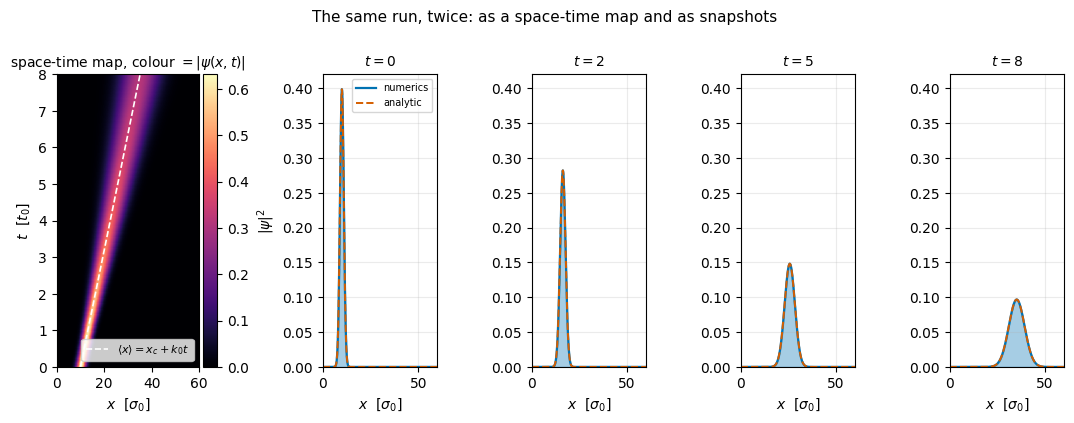

In [23]:
# ==============================================================================
# FIGURE: space-time map + snapshot panels (the fallback for the animations above)
# ==============================================================================
t_map = np.linspace(0.0, T_MAX, 240)
dens_map = np.abs(np.asarray(propagate_times(psi0_j, omega_exact, jnp.asarray(t_map)))) ** 2

fig = plt.figure(figsize=(13.0, 3.8))
gs = fig.add_gridspec(1, 5, width_ratios=[1.5, 1, 1, 1, 1], wspace=0.75)

ax0 = fig.add_subplot(gs[0, 0])
im = ax0.imshow(dens_map ** 0.5, origin="lower", aspect="auto", cmap="magma",
                extent=[0, L, 0, T_MAX], interpolation="nearest")   # sqrt: the faint tails stay visible
ax0.plot(X_C + K0 * t_map, t_map, color="w", ls="--", lw=1.2, label=r"$\langle x\rangle = x_c + k_0t$")
ax0.set_xlabel(r"$x$  [$\sigma_0$]"), ax0.set_ylabel(r"$t$  [$t_0$]")
ax0.set_title(r"space-time map, colour $=|\psi(x,t)|$", fontsize=10)   # the MODULUS, not the density
ax0.legend(fontsize=8, loc="lower right")
fig.colorbar(im, ax=ax0, pad=0.02)

for n, t_s in enumerate([0.0, 2.0, 5.0, 8.0]):
    axn = fig.add_subplot(gs[0, n + 1])
    p_num = np.asarray(propagate(psi0_j, omega_exact, t_s))
    p_ana = psi_exact_ring(x, t_s, X_C, SIGMA0, K0, L)
    axn.fill_between(x, 0, np.abs(p_num) ** 2, color=C_NUM, alpha=0.35)
    axn.plot(x, np.abs(p_num) ** 2, color=C_NUM, lw=1.6, label="numerics")
    axn.plot(x, np.abs(p_ana) ** 2, color=C_ANA, lw=1.4, ls="--", label="analytic")
    axn.set_ylim(0, 0.42), axn.set_xlim(0, L)
    axn.set_title(rf"$t = {t_s:.0f}$", fontsize=10)
    axn.set_xlabel(r"$x$  [$\sigma_0$]")
    axn.grid(alpha=0.25)
    if n == 0:
        axn.set_ylabel(r"$|\psi|^2$"), axn.legend(fontsize=7)
fig.suptitle("The same run, twice: as a space-time map and as snapshots", y=1.05, fontsize=11)
plt.show()

The white dashed line $\langle x\rangle = x_c + k_0 t$ goes straight through the bright ridge — the group
velocity, read off a picture. The ridge fans out symmetrically: that is the spreading, and the opening angle of
the cone is $\pm\sigma_k = \pm 1/(2\sigma_0)$, the velocity spread of the packet.

## 11. What the ring really does: wrap-around, self-interference, revivals

So far we were careful to keep the packet away from the seam. Now let us stop being careful and run for a long
time. Three things will happen, in this order:

1. **Wrap-around.** The packet leaves at $x=L$ and re-enters at $x=0$. Nothing dramatic: on a ring that is just
   "it went around".
2. **Self-interference.** Once $\sigma(t)$ becomes comparable with $L$, the packet's head catches up with its
   own tail. The two parts are the *same* wave function and they interfere — the density develops fringes. The
   infinite-line solution (7) is now simply the wrong formula; the image sum (19) is the right one.
3. **Revival.** At a special time everything comes back exactly.

### 11.1 Time stepping with `lax.scan`

For this animation we produce the frames the way a general-purpose propagator would: one small step at a time.
Our step happens to be exact, but the *loop structure* is the one we will use in every dynamics notebook.

> **JAX practice.** `lax.scan(step, init, xs)` is a compiled `for` loop: it applies `step` repeatedly, carrying
> a state forward and collecting one output per iteration — here the wave function after each step. A Python
> loop of $60$ iterations would be compiled $60$ times; `scan` compiles the body **once**. See
> [01 — JAX from scratch](01_jax_from_scratch.ipynb).

laps completed by t = 45.0: 2.36
width at t = 45.0: sigma = 22.5   (the ring is only L = 60 long!)
max |numerics - IMAGE SUM Eq.(19)| over all frames = 3.446e-13
max |numerics - infinite-line Eq.(7)| at the last frame = 2.875e-02


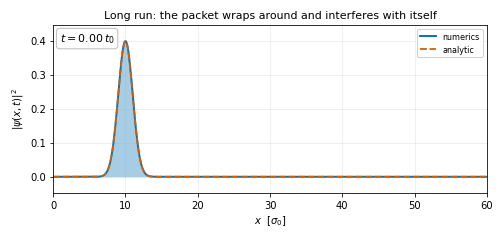

   [60 frames, 0.32 MB embedded in the notebook]


In [24]:
# ==============================================================================
# STEP 9: a time loop with lax.scan (one compiled step, repeated)
# ==============================================================================
@partial(jax.jit, static_argnames="n_steps")
def evolve_frames(psi, omega_k, dt, n_steps):
    """Apply the one-step propagator n_steps times and keep every intermediate state.

    MATH
        psi_{n+1} = IFFT[ exp(-i omega(k) dt) FFT[psi_n] ]
    JAX
        lax.scan compiles the body ONCE; the returned array has shape (n_steps+1, N_x), frame 0 = the input.
    """
    phase = jnp.exp(-1j * omega_k * dt)

    def step(psi_now, _):
        psi_next = jnp.fft.ifft(phase * jnp.fft.fft(psi_now))
        return psi_next, psi_next                       # (carry, output collected by scan)

    _, frames = lax.scan(step, psi, None, length=n_steps)
    return jnp.concatenate([psi[None, :], frames], axis=0)


T_WRAP = 45.0
N_WRAP = 59                                              # 60 frames in total
dt_wrap = T_WRAP / N_WRAP

frames_wrap = np.asarray(evolve_frames(psi0_j, omega_exact, dt_wrap, N_WRAP))
t_wrap = np.arange(N_WRAP + 1) * dt_wrap
dens_wrap = np.abs(frames_wrap) ** 2
dens_wrap_ana = np.abs(np.stack([psi_exact_ring(x, t, X_C, SIGMA0, K0, L, n_images=8)
                                 for t in t_wrap])) ** 2

err_wrap = float(np.max(np.abs(dens_wrap - dens_wrap_ana)))
print(f"laps completed by t = {T_WRAP}: {K0 * T_WRAP / L:.2f}")
print(f"width at t = {T_WRAP}: sigma = {SIGMA0 * np.sqrt(1 + (T_WRAP / (2 * SIGMA0 ** 2)) ** 2):.1f}"
      f"   (the ring is only L = {L:.0f} long!)")
print(f"max |numerics - IMAGE SUM Eq.(19)| over all frames = {err_wrap:.3e}")
print(f"max |numerics - infinite-line Eq.(7)| at the last frame = "
      f"{np.max(np.abs(dens_wrap[-1] - np.abs(psi_exact_line(x, t_wrap[-1], X_C, SIGMA0, K0)) ** 2)):.3e}")
assert err_wrap < 1e4 * TOL, "the method of images must reproduce the ring solution exactly"

make_density_gif(x, dens_wrap, t_wrap, overlay=dens_wrap_ana,
                 title=r"Long run: the packet wraps around and interferes with itself")

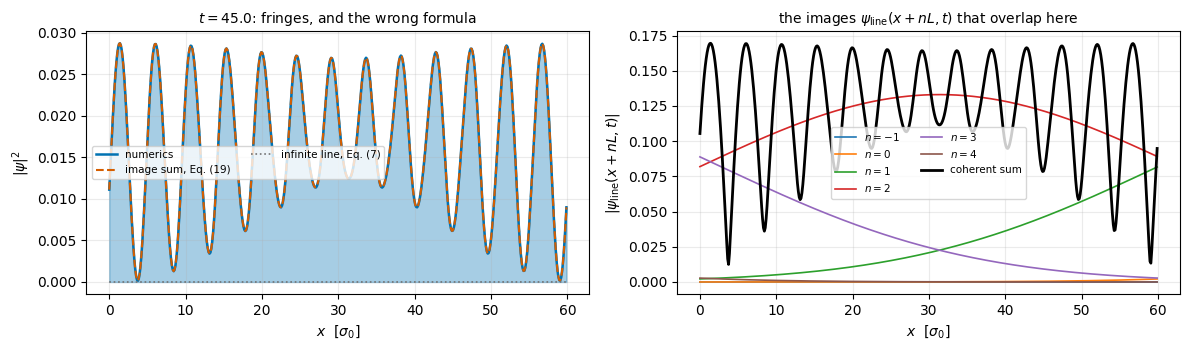

In [25]:
# ==============================================================================
# FIGURE: the last frame, zoomed -- and WHICH images make the fringes
# ==============================================================================
t_last = t_wrap[-1]
fig, axes = plt.subplots(1, 2, figsize=(12.0, 3.6))

axes[0].fill_between(x, 0, dens_wrap[-1], color=C_NUM, alpha=0.35)
axes[0].plot(x, dens_wrap[-1], color=C_NUM, lw=1.8, label="numerics")
axes[0].plot(x, dens_wrap_ana[-1], color=C_ANA, lw=1.5, ls="--", label="image sum, Eq. (19)")
axes[0].plot(x, np.abs(psi_exact_line(x, t_last, X_C, SIGMA0, K0)) ** 2, color="0.45", lw=1.2, ls=":",
             label="infinite line, Eq. (7)")
axes[0].set_xlabel(r"$x$  [$\sigma_0$]"), axes[0].set_ylabel(r"$|\psi|^2$")
axes[0].set_title(rf"$t = {t_last:.1f}$: fringes, and the wrong formula", fontsize=10)

for n in (-1, 0, 1, 2, 3, 4):
    axes[1].plot(x, np.abs(psi_exact_line(x + n * L, t_last, X_C, SIGMA0, K0)), lw=1.2, label=rf"$n={n}$")
axes[1].plot(x, np.abs(np.sum([psi_exact_line(x + n * L, t_last, X_C, SIGMA0, K0) for n in range(-8, 9)],
                              axis=0)), color="k", lw=2.0, label="coherent sum")
axes[1].set_xlabel(r"$x$  [$\sigma_0$]"), axes[1].set_ylabel(r"$|\psi_{\rm line}(x+nL,t)|$")
axes[1].set_title(r"the images $\psi_{\rm line}(x+nL,t)$ that overlap here", fontsize=10)

for ax in axes:
    ax.grid(alpha=0.25), ax.legend(fontsize=7.5, ncol=2)
fig.tight_layout()
plt.show()

**Left:** the final state, over the whole ring. The numerics (blue) and the image sum (dashed orange) coincide
fringe for fringe; the infinite-line formula (dotted grey) is flat zero on this scale, because it puts the
packet at $x_c + k_0t = 151.4$, two and a half turns around the ring — it is simply not the solution of this
problem. The fringe spacing, about $4.7\,\sigma_0$, is the $2\pi t/L = 2\pi\cdot 45/60$ of the physics-insight
box below. **Right:** the individual images. Three of them ($n=1,2,3$) have comparable amplitude in the window
$[0,L)$, and because they are added **as amplitudes, not as probabilities**, their relative phases produce the
fringes. This is the whole of interference in one picture.

Watch the whole story unfold: the packet crosses the seam (disappearing at the right, reappearing at the left),
spreads until it fills a good fraction of the ring, and then develops **interference fringes** — the packet
overlapping its own tail. Those fringes are not noise, not an instability and not a bug: they are real quantum
interference, and the dashed image-sum curve of Eq. (19) reproduces them to $10^{-13}$, as the assert confirms.

Meanwhile the infinite-line formula (7) is off by $3\times10^{-2}$ in the density — of the same order as the
density itself. It is simply not the solution of this problem any more.

> **Physics insight.** The fringe spacing tells you which images interfere. Two copies of the packet separated
> by $\Delta = nL$ produce fringes of period $2\pi/(\Delta/t) = 2\pi t/(nL)$, exactly like a double slit whose
> "slit separation" is $nL$. This is the same mathematics as the interference of two expanding cold-atom
> clouds, which is how the relative phase of two Bose-Einstein condensates is measured.

### 11.2 Exact revivals on a ring

Here is something the infinite line can never do. On the ring the allowed energies are

$$ \omega_n = \frac{k_n^{2}}{2} = \frac{1}{2}\left(\frac{2\pi n}{L}\right)^{2} = \frac{2\pi^{2}n^{2}}{L^{2}} ,
   \qquad n\in\mathbb{Z} . $$

They are all integer multiples of $2\pi^2/L^2$ — **commensurate**. Therefore at the time

$$ T_{\rm rev} = \frac{2\pi}{2\pi^{2}/L^{2}} = \frac{L^{2}}{\pi} $$

every phase factor satisfies $e^{-i\omega_n T_{\rm rev}} = e^{-2\pi i n^{2}} = 1$, so
$\psi(x, T_{\rm rev}) = \psi(x, 0)$ **exactly, for any initial state whatsoever**. The wave function reassembles
itself out of what looked like structureless mush. This is a *quantum revival*; it is the reason a particle in a
box is periodic in time while a classical particle in a box is only quasi-periodic, and it has been observed
with Rydberg wave packets and with cold atoms.

A bonus: at $T_{\rm rev}/2$ the phases are $e^{-i\pi n^2} = (-1)^{n^2} = (-1)^n$, which is precisely the Fourier
multiplier of a **translation by $L/2$**. So at half the revival time the packet reappears on the opposite side
of the ring. At other rational fractions of $T_{\rm rev}$ one finds several smaller copies — "fractional
revivals" — and plotting $\vert\psi(x,t)\vert^2$ over a full revival period produces the famous **quantum
carpet**.

ring L = 20.0,  revival time T_rev = L^2/pi = 127.3240
  || psi(T_rev)   - psi(0)        ||_2 = 1.420e-14   <- a FULL revival
  || psi(T_rev/2) - psi(0) shifted||_2 = 7.108e-15   <- a HALF revival (translated by L/2)
  (the residue is pure round-off: the phases omega_n*T_rev = 2*pi*n^2 reach ~4e3 radians for the modes
   that carry weight (and 1e5 at the band edge), so a relative error of 1e-16 in the argument is
   ~1e-12 radians of phase -- not a method error)


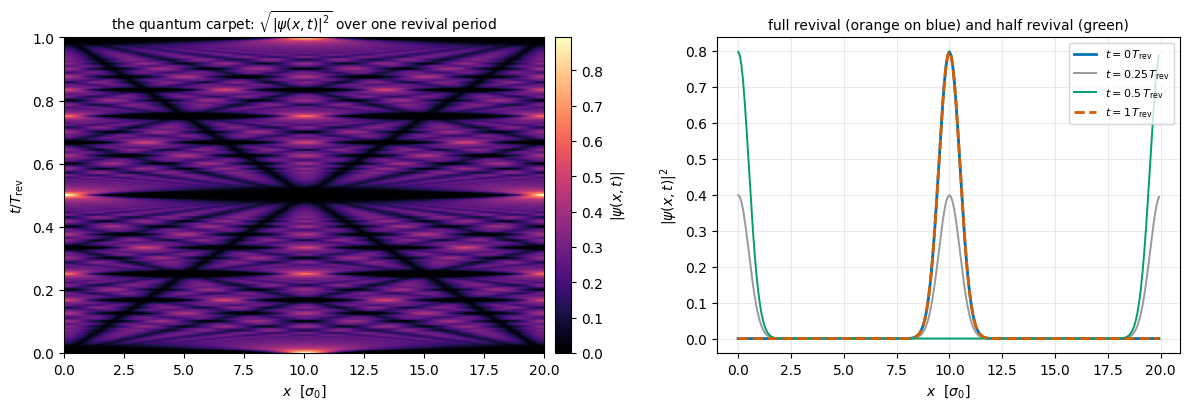

In [26]:
# ==============================================================================
# STEP 10: exact revival on a ring, and the quantum carpet
# ==============================================================================
L_c, N_c = 20.0, 256                                     # a smaller ring, so the carpet has visible structure
x_c2, k_c2, dx_c2 = make_grid(L_c, N_c)
psi0_c2 = jnp.asarray(gaussian_packet(x_c2, 0.5 * L_c, 0.5, 0.0))
omega_c2 = jnp.asarray(0.5 * k_c2 ** 2, dtype=RDTYPE)
T_REV = L_c ** 2 / np.pi

psi_rev = np.asarray(propagate(psi0_c2, omega_c2, T_REV))
psi_half = np.asarray(propagate(psi0_c2, omega_c2, 0.5 * T_REV))
psi_shift = np.roll(np.asarray(psi0_c2), N_c // 2)       # the initial state translated by L/2

err_rev = l2_error(psi_rev, np.asarray(psi0_c2), dx_c2)
err_half = l2_error(psi_half, psi_shift, dx_c2)
print(f"ring L = {L_c},  revival time T_rev = L^2/pi = {T_REV:.4f}")
print(f"  || psi(T_rev)   - psi(0)        ||_2 = {err_rev:.3e}   <- a FULL revival")
print(f"  || psi(T_rev/2) - psi(0) shifted||_2 = {err_half:.3e}   <- a HALF revival (translated by L/2)")
print("  (the residue is pure round-off: the phases omega_n*T_rev = 2*pi*n^2 reach ~4e3 radians for the modes")
print("   that carry weight (and 1e5 at the band edge), so a relative error of 1e-16 in the argument is")
print("   ~1e-12 radians of phase -- not a method error)")
assert err_rev < 1e4 * TOL and err_half < 1e4 * TOL

t_carpet = np.linspace(0.0, T_REV, 500)
carpet = np.abs(np.asarray(propagate_times(psi0_c2, omega_c2, jnp.asarray(t_carpet)))) ** 2

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), gridspec_kw={"width_ratios": [1.25, 1]})
im = axes[0].imshow(carpet ** 0.5, origin="lower", aspect="auto", cmap="magma",
                    extent=[0, L_c, 0, T_REV / T_REV], interpolation="nearest")
axes[0].set_xlabel(r"$x$  [$\sigma_0$]"), axes[0].set_ylabel(r"$t / T_{\rm rev}$")
axes[0].set_title(r"the quantum carpet: $\sqrt{|\psi(x,t)|^2}$ over one revival period", fontsize=10)
fig.colorbar(im, ax=axes[0], pad=0.02, label=r"$|\psi(x,t)|$")

for frac, col, ls in ((0.0, C_NUM, "-"), (0.25, "0.6", "-"), (0.5, C_FD, "-"), (1.0, C_ANA, "--")):
    p = np.asarray(propagate(psi0_c2, omega_c2, frac * T_REV))
    axes[1].plot(x_c2, np.abs(p) ** 2, ls, color=col, lw=2.0 if frac in (0.0, 1.0) else 1.4,
                 label=rf"$t = {frac:g}\,T_{{\rm rev}}$")
axes[1].set_xlabel(r"$x$  [$\sigma_0$]"), axes[1].set_ylabel(r"$|\psi(x,t)|^2$")
axes[1].set_title("full revival (orange on blue) and half revival (green)", fontsize=10)
axes[1].legend(fontsize=8), axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

The carpet is one of the prettiest pictures in quantum mechanics: a lattice of dark "canals" (where the
probability density nearly vanishes along a straight line in the $x$-$t$ plane) crossed by bright "ridges",
woven by the interference of the ring's commensurate energy levels. Read it from the bottom up: the
packet spreads, fills the ring, produces ever finer fringes, and then — at $t = T_{\rm rev}$, the top edge —
every fringe collapses back into the original single lump. The right panel confirms it quantitatively: the
curve at $t = T_{\rm rev}$ (orange dashed) lies exactly on the curve at $t=0$ (blue), and at
$t = T_{\rm rev}/2$ (green) the packet sits at the antipode, $x = L/2$ away.

The asserts put a number on "exactly": the state at $t=T_{\rm rev}$ differs from the initial one by
$1.4\times10^{-14}$ in the $L^2$ norm — round-off, nothing else. That is a little impressive in itself: the
phases $\omega_n T_{\rm rev} = 2\pi n^2$ reach $\approx 4\times10^{3}$ radians for the highest modes that
still carry any weight ($\vert n\vert \approx 26$ here), and $10^{5}$ radians at the edge of the band, and an
error of one part in $10^{16}$ in such an argument is still only $10^{-12}$ radians of phase.

## 12. Summary

### Key takeaways

* **Non-dimensionalise first.** The free particle has no intrinsic length, so we chose one, $x_0 = \sigma_0$,
  and derived $t_0 = m x_0^2/\hbar$, $E_0 = \hbar^2/(m x_0^2)$, $v_0 = \hbar/(m x_0)$. The equation becomes
  $i\,\partial_t\psi = -\tfrac12\partial_x^2\psi$, with no $\hbar$ and no $m$, and one simulation then covers an
  electron at the femtosecond scale and a rubidium cloud at the millisecond scale.
* **A Gaussian packet moves and spreads**: $\langle x\rangle = x_c + k_0t$ (group velocity $k_0$, twice the
  phase velocity) and $\sigma(t) = \sigma_0\sqrt{1+(t/2\sigma_0^2)^2}$, so narrower packets spread *faster*.
  The momentum distribution never changes; the uncertainty product grows; the packet acquires a chirp,
  $k_{\rm loc}\to k_0 + X/t$.
* **Ehrenfest and the ballistic law.** $d\langle x\rangle/dt = \langle p\rangle$ and $d\langle p\rangle/dt = 0$
  (no force), so the centre moves classically; the momentum distribution is frozen, and the width obeys
  $\mathrm{Var}(x)(t) = \mathrm{Var}(x)(0) + \mathrm{Var}(p)\,t^{2}$ — the same variance-addition law as a
  classical swarm of particles with a spread of velocities. The covariance $C(t) = \mathrm{Var}(p)\,t$ *is* the
  chirp, and the uncertainty product $1/4 + t^2/16\sigma_0^4$ leaves the Heisenberg minimum immediately.
* **The operator you measure with is a separate approximation from the propagator.** On a grid that gave the
  density to $10^{-14}$, the central-difference $\langle p\rangle$ was still $2\%$ off, exactly as
  $\sin(k_0\Delta x)/\Delta x$ predicts, while the Fourier-space estimator was exact.
* **A grid is a physical model, not just an approximation.** The three-point Laplacian replaces $\omega=k^2/2$
  by $\omega_{\rm FD}=(1-\cos k\Delta x)/\Delta x^2$; the resulting packet moves at $\sin(k_0\Delta x)/\Delta x$,
  too slowly, and spreads too slowly by the factor $\cos(k_0\Delta x)$, with an error $O(\Delta x^2)$ that we
  measured (fitted slope $1.99$).
* **With periodic boundaries the Fourier method is unbeatable**: one FFT, one phase, one inverse FFT is
  *exact in time* and *spectrally accurate in space*, at $O(N_x\log N_x)$. At $N_x=128$ it was already
  fourteen orders of magnitude more accurate than the stencil, which would have needed $\sim 10^9$ points to
  catch up.
* **Always ask what you compare against.** The ring is not the line; the exact ring solution is the image sum
  (19). Comparing with the wrong reference produced a spurious error floor at $10^{-8}$.
* **The ring has its own physics**: wrap-around, self-interference fringes, and exact revivals at
  $T_{\rm rev}=L^2/\pi$ (with a translated half-revival at $T_{\rm rev}/2$) — because the energies
  $2\pi^2n^2/L^2$ are all commensurate.
* **Respect the sampling theorem.** The grid holds $\vert k\vert\le\pi/\Delta x$ and nothing else; ask for a
  mode index above $N_x/2$ and it silently stores the negative index $m-N_x$ instead, sending your packet the
  other way.

### The workflow checklist — reuse this for every simulation you ever write

1. **Non-dimensionalise.** Choose the units from the problem; make every variable of order $1$.
2. **Discretise, and write down the error.** Which approximation, which order, which grid parameters control it.
3. **Check the trivial things first.** Norm, mean position, width of the *initial* state, against their analytic
   values. Most bugs die here.
4. **Identify the conserved quantities** and monitor them along the run (norm, energy, momentum, particle
   number, symmetry sectors).
5. **Run a convergence test.** Refine the grid (and/or the time step) and verify that the error falls at the
   *predicted rate*, on a log-log plot with a fitted slope. "It looks converged" is not a result.
6. **Compare with a known limit** — an exact solution, a second independent algorithm, a published number, or a
   simplified case you can do by hand.
7. **Only then** change the parameters and explore new physics. And when the new physics looks surprising,
   repeat steps 4–6 before believing it.

### Exercises

1. (★) **Narrow packets spread faster.** Run the spectral method for $\sigma_0 \in \{0.5, 1, 2\}$ (keep
   $k_0=0$), measure $\sigma(t)$ with `packet_width`, and verify $\sigma(t)=\sigma_0\sqrt{1+(t/2\sigma_0^2)^2}$.
   Check that the time at which the width has grown by $\sqrt2$ is $t_s = 2\sigma_0^2$. Which packet is the
   widest at $t=10$? Explain the crossing of the curves.
2. (★) **Two packets collide.** Take $\psi(x,0) \propto \psi_{\rm G}(x; x_1, \sigma_0, +k_0) +
   \psi_{\rm G}(x; x_2, \sigma_0, -k_0)$ with $x_1 = L/4$, $x_2 = 3L/4$ (normalise it!). Animate the collision.
   Measure the fringe spacing in the overlap region and compare with $\pi/k_0$ (the two-plane-wave result).
   Do the packets "bounce"? Why not?
3. (★★) **Measure the numerical group velocity.** Repeat the checkpoint of Section 7.2 for
   $k_0\Delta x \in \{0.1, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0\}$ (adjust $N_x$, keeping $k_0$ commensurate) and plot
   the measured velocity against $\sin(k_0\Delta x)/\Delta x$. Above which value of $k_0\Delta x$ does the
   finite-difference packet get *slower* when you increase $k_0$? What happens as $k_0\Delta x\to\pi$? Then
   push $k_0$ *past* the Nyquist limit and watch both methods send the packet the wrong way — that failure is
   aliasing, not the stencil.
4. (★★) **A fourth-order stencil.** The five-point Laplacian is
   $(-\psi_{j+2} + 16\psi_{j+1} - 30\psi_j + 16\psi_{j-1} - \psi_{j-2})/(12\Delta x^2)$. Show by Taylor
   expansion that it is $O(\Delta x^4)$, derive its dispersion relation
   $\omega_4(k) = \big(15 - 16\cos(k\Delta x) + \cos(2k\Delta x)\big)/(12\Delta x^2)$, feed it to `propagate`,
   and add it to the convergence plot. Is the fitted slope $4$?
5. (★★) **Phase versus group velocity.** From the animation of $\mathrm{Re}\,\psi$, track one crest (find the
   zero crossings of $\mathrm{Re}\,\psi$ near the peak) and measure its velocity. Confirm that it is $k_0/2$
   while the envelope moves at $k_0$.
6. (★★) **Revivals on your own ring.** Change $L$ and verify $T_{\rm rev}=L^2/\pi$ numerically. What happens at
   $t = T_{\rm rev}/3$? Plot it. (These are *fractional revivals*: three copies of the packet.)
7. (★★★) **A potential step.** A free particle is boring in the end; the interesting physics is scattering. The
   split-step recipe extends `propagate` to a Hamiltonian $H = \hat p^2/2 + V(x)$: apply
   $e^{-iV\Delta t/2}$ in position space, then $e^{-ik^2\Delta t/2}$ in Fourier space, then
   $e^{-iV\Delta t/2}$ again. Implement it, send a packet of energy $E=k_0^2/2$ at a step $V(x)=V_0$ for
   $x>L/2$, and measure the transmitted probability for $V_0/E \in \{0.5, 0.9, 1.0, 1.1, 2\}$. Compare with the
   textbook plane-wave transmission coefficient. Why is the agreement imperfect? (Notebook 00b builds the
   machinery for potentials properly.)
8. (★★★) **The Wigner function.** Compute
   $W(x,p) = \frac{1}{\pi}\int \psi^{*}(x+y)\,\psi(x-y)\,e^{2ipy}\,dy$ on the grid and animate it. For the free
   particle it should simply shear: $W(x,p,t) = W(x-pt, p, 0)$ — the exact classical Liouville flow. Verify
   that, and explain why the free particle is the one case where quantum and classical phase-space dynamics
   agree exactly.

### References

* D. J. Griffiths and D. F. Schroeter, *Introduction to Quantum Mechanics*, 3rd ed., Cambridge University Press
  (2018) — Chapter 2: the free particle and the Gaussian wave packet, worked out in detail.
* J. J. Sakurai and J. Napolitano, *Modern Quantum Mechanics*, 3rd ed., Cambridge University Press (2020) —
  §1.7.4 (Gaussian wave packets and minimum-uncertainty states) and §2.2.4 (free particles, Ehrenfest's theorem).
* D. J. Tannor, *Introduction to Quantum Mechanics: A Time-Dependent Perspective*, University Science Books
  (2007) — the standard reference for wave-packet dynamics and grid methods; Chapters 1–2 and 11.
* M. D. Feit, J. A. Fleck Jr. and A. Steiger, *Solution of the Schrödinger equation by a spectral method*,
  J. Comput. Phys. **47**, 412–433 (1982) — the split-operator Fourier method.
* D. Kosloff and R. Kosloff, *A Fourier method solution for the time dependent Schrödinger equation as a tool in
  molecular dynamics*, J. Comput. Phys. **52**, 35–53 (1983) — the Fourier grid method used in Section 7.
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes*, 3rd ed., Cambridge
  University Press (2007) — Chapter 12 for the FFT, Chapter 20 for partial differential equations.
* L. N. Trefethen, *Spectral Methods in MATLAB*, SIAM (2000) — why periodic trapezoidal sums and spectral
  differentiation converge exponentially.
* R. W. Robinett, *Quantum wave packet revivals*, Phys. Rep. **392**, 1 (2004) — revivals, fractional revivals
  and quantum carpets.

### What comes next

[00b — a first quantum simulation: the harmonic oscillator](00b_first_quantum_simulation_harmonic_oscillator.ipynb)
puts the particle in a trap: a potential, a tridiagonal Hamiltonian matrix, diagonalisation into stationary
states, a frequency quench, and two more ways to propagate (the matrix exponential and Runge–Kutta).
Then [01 — JAX from scratch](01_jax_from_scratch.ipynb) explains the three JAX tools we used today —
`jit`, `vmap` and `scan` — together with automatic differentiation, and the course proper begins.
[49 — a single excitation on a lattice](../lecture_notes_notebooks/49_single_excitation_on_a_lattice.ipynb) needs
nothing beyond this notebook and can be read at any point after it: it takes the three-point Laplacian of Section 6
and reads it as the exact Hamiltonian of a particle hopping on a lattice, so that the dispersion
$\omega_{\rm FD}(k)$, an artefact here, becomes the true band structure there.

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/